In [1]:
# !pip install torch==2.3.0 torchvision==0.18.0 torchaudio==2.3.0 --index-url https://download.pytorch.org/whl/cu121
# !pip install  dgl -f https://data.dgl.ai/wheels/torch-2.3/cu121/repo.html
# !pip install seaborn

## Configuración:
* Importación Librerias
* Definición rutas
* Definición funciones auxiliares

In [1]:
# Reload modulos automaticamente
%load_ext autoreload
%autoreload 2


from modules.gnn_models import (
    GCN2L,
    GraphSAGE2L,
    GAT2L,
    GCN3L,
    GraphSAGE3L,
    GAT3L,
    GCNSampler2L,
    GraphSAGESample2L,
    GATSample2L
)

from modules.gnn import GNN
import itertools
import csv
import os
import dgl
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
)

print("DGL:", dgl.__version__, " | PyTorch:", torch.__version__)
TOR_LABELS_DICT = {'P2P': 0, 'C2P': 1, 'P2C': 2}

DGL: 1.1.3  | PyTorch: 2.3.0+cu121


### Funciones Auxiliares plot

In [2]:
def plot_confusion_matrix(cm,
                          classes,
                          normalize=False,
                          title='Confusion matrix',
                          fname=None,
                          cmap=plt.cm.Blues,
                          save=False):
    """
    Print and plot the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix (not normalized)')

    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], fmt),
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    
    if save and fname is not None:
        plt.savefig(f"{fname}.png", dpi=300, bbox_inches='tight')
    plt.show()

def plot_confusion_matrix_2(cm,
                            classes,
                            normalize=False,
                            title='Confusion matrix',
                            fname=None,
                            cmap=plt.cm.Blues,
                            save=False):
    """
    Plot confusion matrix.
    If `normalize=True`, values are shown in percentage (%).
    """
    if normalize:
        cm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100  # -> %
        print("Normalized confusion matrix (%)")
        fmt  = ".1f"
        suffix = "%"
    else:
        print("Confusion matrix (not normalized)")
        fmt  = "d"
        suffix = ""

    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title); plt.colorbar()
    ticks = np.arange(len(classes))
    plt.xticks(ticks, classes, rotation=45)
    plt.yticks(ticks, classes)

    thresh = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i,
                     f"{format(cm[i, j], fmt)}{suffix}",
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black")

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()

    # if save and fname:
        # plt.savefig(f"{fname}.png", dpi=300, bbox_inches="tight")
    plt.show()

## Entrenamiento

In [3]:
from pathlib import Path

# Archivos del nuevo formato de grafo (nodos/aristas)
data_path = Path("/media/vale/KINGSTON/TESIS/data_2026")
nodes_file = data_path / "nodes_rib_20260301_0000_to_20260302_0000_enriched_tesis.csv"
edges_file = data_path / "edges_rib_20260301_0000_to_20260302_0000_enriched_tesis.csv"

# nodes_file = data_path / "nodes_rib_20260301_0000_to_20260302_0000_pruned_enriched_tesis.csv"
# edges_file = data_path / "edges_rib_20260301_0000_to_20260302_0000_pruned_enriched_tesis.csv"

if not nodes_file.exists():
    raise FileNotFoundError(f"No existe el archivo de nodos: {nodes_file}")
if not edges_file.exists():
    raise FileNotFoundError(f"No existe el archivo de aristas: {edges_file}")

print(f"Nodos: {nodes_file}")
print(f"Aristas: {edges_file}")



Nodos: /media/vale/KINGSTON/TESIS/data_2026/nodes_rib_20260301_0000_to_20260302_0000_enriched_tesis.csv
Aristas: /media/vale/KINGSTON/TESIS/data_2026/edges_rib_20260301_0000_to_20260302_0000_enriched_tesis.csv


In [4]:
import time



GLOBAL_CONFIG = {
'lr': 0.001,
'hidden_dim': 256,
'out_dim': 128,
'epochs': 500,
'patience': 120,
'weight_decay': 5e-4,
'dropout': 0.3,
'label_smooth': 0.05,
'grad_clip': 2.0,
'num_heads': 2,
'batch_size': 1024, #4
'num_neighbors': 15, # Para GraphSAGE/GAT con muestreo
'focal_gamma': 2.0, # Focal loss gamma
}


In [5]:
import torch
import torch.nn.functional as F

def focal_loss(logits, targets, alpha=None, gamma=2.0, reduction='mean'):
    """Focal loss multiclase. gamma=0 equivale a cross-entropy pesada."""
    ce = F.cross_entropy(logits, targets, weight=alpha, reduction='none')
    with torch.no_grad():
        probs = F.softmax(logits, dim=1)
        p_t   = probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        w     = (1.0 - p_t) ** gamma
    loss = w * ce
    if reduction == 'mean':  return loss.mean()
    if reduction == 'sum':   return loss.sum()
    return loss


In [6]:
# from pathlib import Path

# # Archivos del nuevo formato de grafo (nodos/aristas)
# nodes_file = "/media/vale/KINGSTON/TESIS/data/RIBs/nodes_sanitized_rib_marzo_2024_enriched_tesis.csv"
# edges_file = "/media/vale/KINGSTON/TESIS/data/RIBs/edges_sanitized_rib_marzo_2024_enriched_tesis.csv"

# if not Path(nodes_file).exists():
#     raise FileNotFoundError(f"No existe el archivo de nodos: {nodes_file}")
# if not Path(edges_file).exists():
#     raise FileNotFoundError(f"No existe el archivo de aristas: {edges_file}")

# print(f"Nodos: {nodes_file}")
# print(f"Aristas: {edges_file}")


## Caso 0: Se utiliza grafo con atributos de nodos extraídos de PeeringDB

In [7]:
# 1. Load data with the new format (node_id/asn + src_id/dst_id/relationship)
gnn = GNN(debug=True)
gnn.load_dataset(str(nodes_file), str(edges_file))

gnn.split_edges_classification(
    train_size=0.7,
    val_size=0.15,
    seed=42,
    balance_mode="proportional",  # usa todos los datos; class_weights compensan el desbalance
)

g0 = gnn.dgl_graph
print("\n[Loaded graph summary]")
print(f"- Nodes: {g0.num_nodes():,}")
print(f"- Edges: {g0.num_edges():,}")
print(f"- Feature dimension: {g0.ndata['feat'].shape[1]}")
print(f"- Edge data keys: {list(g0.edata.keys())}")
print(f"- Train edges: {g0.edata['train_mask'].sum().item():,}")
print(f"- Validation edges: {g0.edata['val_mask'].sum().item():,}")
print(f"- Test edges: {g0.edata['test_mask'].sum().item():,}")
if "label" in g0.edata:
    print(f"- Global label distribution: {Counter(g0.edata['label'].tolist())}")
    tr = g0.edata['label'][g0.edata['train_mask']]
    va = g0.edata['label'][g0.edata['val_mask']]
    te = g0.edata['label'][g0.edata['test_mask']]
    print(f"- Train distribution: {Counter(tr.tolist())}")
    print(f"- Validation distribution: {Counter(va.tolist())}")
    print(f"- Test distribution: {Counter(te.tolist())}")

    # 10 seg

Grafo cargado: 79504 nodos, 807496 aristas
Aristas en ambos sentidos: True
Dimensión de entrada (in_feats): 72
Edge features: 1 dim

[SPLIT COMPLETO - ESTRATIFICADO]
Modo balanceo: proportional
Etiqueta usada: label
Total aristas etiquetadas: 660438
Train: 462306 | Val: 99064 | Test: 99068
Distribución Train: {0: 238358, 2: 111974, 1: 111974}
Distribución Val:   {0: 51076, 1: 23994, 2: 23994}
Distribución Test:  {2: 23995, 1: 23995, 0: 51078}

[Loaded graph summary]
- Nodes: 79,504
- Edges: 807,496
- Feature dimension: 72
- Edge data keys: ['label', 'edge_feat', 'train_mask', 'val_mask', 'test_mask']
- Train edges: 462,306
- Validation edges: 99,064
- Test edges: 99,068
- Global label distribution: Counter({0: 340512, 1: 159963, 2: 159963, -1: 147058})
- Train distribution: Counter({0: 238358, 1: 111974, 2: 111974})
- Validation distribution: Counter({0: 51076, 1: 23994, 2: 23994})
- Test distribution: Counter({0: 51078, 1: 23995, 2: 23995})


In [8]:
models = {
    # 'GCN': GCN3L,
    'GraphSAGE': GraphSAGE3L,
    'GAT': GAT3L,
}

# models = {
#     'GCN': GCN2L,
#     'GraphSAGE': GraphSAGE2L,
#     'GAT': GAT2L,
# }


### Encoder : decodeBilinear

In [9]:

# # 1.- Definición parámetros (usar config global)
# # ----------------------------------------------
# in_feats      = gnn.dgl_graph.ndata["feat"].shape[1]
# hidden_feats  = GLOBAL_CONFIG['hidden_dim']
# emb_dim       = GLOBAL_CONFIG['out_dim']
# lr            = GLOBAL_CONFIG['lr']
# device        = "cuda" if torch.cuda.is_available() else "cpu"

# # 2.- Datos y máscaras
# # ----------------------------------------------
# g       = gnn.dgl_graph.to(device)
# feat    = g.ndata["feat"].to(device)
# g.ndata["log_out_deg"] = torch.log1p(g.out_degrees().float()).to(device)
# g.ndata["log_in_deg"]  = torch.log1p(g.in_degrees().float()).to(device)




In [10]:

# label_key = next((k for k in ["label", "relationship", "Relationship"] if k in g.edata), None)
# if label_key is None:
#     raise KeyError(f"Label column not found in edata. Available keys: {list(g.edata.keys())}")
# labels = g.edata[label_key].long().to(device)

# train_m = g.edata["train_mask"].bool().to(device)
# val_m   = g.edata["val_mask"].bool().to(device) if "val_mask" in g.edata else None
# test_m  = g.edata["test_mask"].bool().to(device)

# if train_m.sum().item() == 0 or test_m.sum().item() == 0:
#     raise ValueError("train_mask/test_mask are empty. Check split_edges_classification().")
# if val_m is None or val_m.sum().item() == 0:
#     raise ValueError("val_mask is empty/not found. Use split_edges_classification with val_size > 0.")

# labeled_m = train_m | val_m | test_m
# n_classes = int(labels[labeled_m].max().item()) + 1

# # Class weights to reduce collapse into a dominant class
# class_counts = torch.bincount(labels[train_m], minlength=n_classes).float()
# class_weights = (class_counts.sum() / (n_classes * class_counts.clamp(min=1.0))).to(device)

# default_names = ["P2P", "C2P", "P2C"]
# class_names = default_names[:n_classes] if n_classes <= len(default_names) else [f"Class {i}" for i in range(n_classes)]

# print(f"Using device: {device}")
# print(f"Using edge label key: {label_key}")
# print(f"Number of classes detected: {n_classes}")
# print(f"Train class counts: {class_counts.tolist()}")
# print(f"Class weights: {class_weights.tolist()}")

# # 3.- Load node_id -> asn mapping for readable inference export
# id_to_asn = {}
# with open(nodes_file, newline="") as f:
#     reader = csv.DictReader(f)
#     for row in reader:
#         id_to_asn[int(row["node_id"])] = int(row["asn"])

# # 4.- Output directories
# output_root = Path("./results/end_to_end")
# plot_dir = output_root / "plots"
# pred_dir = output_root / "predictions"
# plot_dir.mkdir(parents=True, exist_ok=True)
# pred_dir.mkdir(parents=True, exist_ok=True)
# run_tag = edges_file.stem.replace("edges_", "")

# # 5.- Training per model (Bilinear Decoder)
# for name, Model in models.items():
#     print(f"\nTraining {name} (Bilinear)\n" + "-" * 40)

#     history = {"loss_tr": [], "acc_tr": [], "loss_val": [], "acc_val": [], "f1_val": []}
#     extra_kw = {'num_heads': GLOBAL_CONFIG['num_heads']} if 'GAT' in name else {}
#     model = Model(in_feats,
#                   GLOBAL_CONFIG['hidden_dim'],
#                   GLOBAL_CONFIG['out_dim'],
#                   out_feats_mlp=n_classes,
#                   drop=GLOBAL_CONFIG['dropout'],
#                   **extra_kw).to(device)
    
#     opt = torch.optim.Adam(model.parameters(), lr=GLOBAL_CONFIG['lr'], weight_decay=GLOBAL_CONFIG['weight_decay'])
#     scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(opt, T_0=50, T_mult=2)

#     best_macro_f1, best_val_loss, wait, best_w = -1.0, float("inf"), 0, None

#     t0 = time.perf_counter()
#     for epoch in range(1, GLOBAL_CONFIG['epochs'] + 1):
#         model.train()
#         h = model.encode(g, feat)
#         logits = model.decodeBilinear(g, h)


#         # loss = F.cross_entropy(logits[train_m], 
#         #                        labels[train_m], 
#         #                        weight=class_weights, 
#         #                        label_smoothing=GLOBAL_CONFIG['label_smooth'])
        

#         loss = F.cross_entropy(logits[train_m], 
#                                labels[train_m], 

#                                label_smoothing=GLOBAL_CONFIG['label_smooth'])
        

#         opt.zero_grad()
#         loss.backward()
#         torch.nn.utils.clip_grad_norm_(model.parameters(), GLOBAL_CONFIG['grad_clip'])
#         opt.step()
#         scheduler.step(epoch - 1 + (1 / GLOBAL_CONFIG['epochs']))

#         with torch.no_grad():
#             preds_tr = logits[train_m].argmax(1)
#             acc_tr = (preds_tr == labels[train_m]).float().mean().item()

#         model.eval()
#         with torch.no_grad():
#             logits_val = model.decodeBilinear(g, model.encode(g, feat))

#             # loss_val = F.cross_entropy(logits_val[val_m], 
#             #                            labels[val_m], 
#             #                            weight=class_weights
#             #                            )
            
#             loss_val = F.cross_entropy(logits_val[val_m], 
#                                        labels[val_m])


#             preds_val = logits_val[val_m].argmax(1)
#             val_true = labels[val_m]
#             acc_val = (preds_val == val_true).float().mean().item()
#             macro_f1_val = f1_score(
#                 val_true.cpu().numpy(),
#                 preds_val.cpu().numpy(),
#                 average="macro",
#                 zero_division=0,
#             )

#         history["loss_tr"].append(loss.item())
#         history["acc_tr"].append(acc_tr * 100)
#         history["loss_val"].append(loss_val.item())
#         history["acc_val"].append(acc_val * 100)
#         history["f1_val"].append(macro_f1_val * 100)

#         improved_f1 = macro_f1_val > (best_macro_f1 + 1e-4)
#         tie_break_loss = abs(macro_f1_val - best_macro_f1) <= 1e-4 and loss_val.item() < (best_val_loss - 1e-4)

#         if improved_f1 or tie_break_loss:
#             best_macro_f1, best_val_loss, wait = macro_f1_val, loss_val.item(), 0
#             best_w = model.state_dict()
#         else:
#             wait += 1
#             if wait >= GLOBAL_CONFIG['patience']:
#                 print(f"Early stop at epoch {epoch} (best val macro-F1={best_macro_f1*100:.2f}%)")
#                 break

#         if epoch % 10 == 0 or epoch == 1:
#             print(
#                 f"ep{epoch:03d} | loss_tr {loss:.4f} acc_tr {acc_tr:.2%} | "
#                 f"loss_val {loss_val:.4f} acc_val {acc_val:.2%} f1_val {macro_f1_val:.2%}"
#             )

#     tiempo_total = time.perf_counter() - t0
#     mins, secs = divmod(tiempo_total, 60)
#     print(f"\n{'='*50}")
#     print(f"[TIEMPO] {name} (Bilinear): {int(mins)}m {secs:.1f}s  ({tiempo_total:.1f}s total)")
#     print(f"{'='*50}")

#     if best_w is not None:
#         model.load_state_dict(best_w)

#     with torch.no_grad():
#         logits_best = model.decodeBilinear(g, model.encode(g, feat))
#         preds_best = logits_best[test_m].argmax(1).cpu()
#         truth = labels[test_m].cpu()

#     cm = confusion_matrix(truth, preds_best, labels=list(range(n_classes)))
#     plot_confusion_matrix_2(cm, classes=class_names, normalize=False, title=f"Confusion Matrix - {name}")
#     plot_confusion_matrix_2(cm, classes=class_names, normalize=True, title=f"Confusion Matrix (%) - {name}")

#     print(classification_report(truth, preds_best, digits=4, zero_division=0, target_names=class_names))

#     # Baseline: always predict the majority train class
#     majority_class = int(torch.mode(labels[train_m]).values.item())
#     baseline_preds = torch.full_like(truth, fill_value=majority_class)
#     baseline_acc = accuracy_score(truth, baseline_preds) * 100
#     baseline_f1_macro = f1_score(truth, baseline_preds, average="macro", zero_division=0) * 100

#     prec_micro = precision_score(truth, preds_best, average="micro", zero_division=0) * 100
#     rec_micro  = recall_score(truth, preds_best, average="micro", zero_division=0) * 100
#     f1_micro   = f1_score(truth, preds_best, average="micro", zero_division=0) * 100
#     acc        = accuracy_score(truth, preds_best) * 100

#     prec_macro = precision_score(truth, preds_best, average="macro", zero_division=0) * 100
#     rec_macro  = recall_score(truth, preds_best, average="macro", zero_division=0) * 100
#     f1_macro   = f1_score(truth, preds_best, average="macro", zero_division=0) * 100

#     prec_w = precision_score(truth, preds_best, average="weighted", zero_division=0) * 100
#     rec_w  = recall_score(truth, preds_best, average="weighted", zero_division=0) * 100
#     f1_w   = f1_score(truth, preds_best, average="weighted", zero_division=0) * 100

#     recalls_per_class = recall_score(
#         truth,
#         preds_best,
#         average=None,
#         labels=list(range(n_classes)),
#         zero_division=0,
#     )

#     print(f"[BASELINE] Majority class={majority_class} ({class_names[majority_class] if majority_class < len(class_names) else majority_class})")
#     print(f"[BASELINE] Acc={baseline_acc:.2f}% | Macro-F1={baseline_f1_macro:.2f}%")
#     print(f"[MODEL]    Acc={acc:.2f}% | Macro-F1={f1_macro:.2f}%")
#     print(f"[TEST] micro:    Prec={prec_micro:.2f}%  Rec={rec_micro:.2f}%  F1={f1_micro:.2f}% | Acc={acc:.2f}%")
#     print(f"[TEST] macro:    Prec={prec_macro:.2f}%  Rec={rec_macro:.2f}%  F1={f1_macro:.2f}%")
#     print(f"[TEST] weighted: Prec={prec_w:.2f}%  Rec={rec_w:.2f}%  F1={f1_w:.2f}%")

#     print("Recall per class (test):")
#     for i, r in enumerate(recalls_per_class):
#         cname = class_names[i] if i < len(class_names) else f"Class {i}"
#         print(f"  - {cname}: {r*100:.2f}%")

#     epoch_axis = range(1, len(history["loss_tr"]) + 1)

#     plt.figure(figsize=(8, 4))
#     plt.plot(epoch_axis, history["loss_tr"], label="Train Loss")
#     plt.plot(epoch_axis, history["loss_val"], label="Validation Loss")
#     plt.xlabel("Epoch")
#     plt.ylabel("Loss")
#     plt.title(f"Loss Curve - {name}")
#     plt.legend()
#     plt.tight_layout()
#     plt.savefig(plot_dir / f"loss_{name}_{run_tag}_bilinear.png", dpi=300, bbox_inches='tight')
#     plt.show()

#     plt.figure(figsize=(8, 4))
#     plt.plot(epoch_axis, history["acc_tr"], label="Train Accuracy (%)")
#     plt.plot(epoch_axis, history["acc_val"], label="Validation Accuracy (%)")
#     plt.xlabel("Epoch")
#     plt.ylabel("Accuracy (%)")
#     plt.title(f"Accuracy Curve - {name}")
#     plt.ylim(0, 100)
#     plt.legend()
#     plt.tight_layout()
#     plt.savefig(plot_dir / f"accuracy_{name}_{run_tag}_bilinear.png", dpi=300, bbox_inches='tight')
#     plt.show()

#     plt.figure(figsize=(8, 4))
#     plt.plot(epoch_axis, history["f1_val"], label="Validation Macro-F1 (%)", color="purple")
#     plt.xlabel("Epoch")
#     plt.ylabel("Macro-F1 (%)")
#     plt.title(f"Validation Macro-F1 Curve - {name}")
#     plt.ylim(0, 100)
#     plt.legend()
#     plt.tight_layout()
#     plt.savefig(plot_dir / f"macrof1_val_{name}_{run_tag}_bilinear.png", dpi=300, bbox_inches='tight')
#     plt.show()

#     out_file = pred_dir / f"inference_results_{name}_{run_tag}_bilinear.txt"
#     u, v = g.edges()
#     test_eids = torch.where(test_m)[0].cpu().tolist()
#     with open(out_file, "w") as f:
#         f.write("src_id|dst_id|src_asn|dst_asn|pred|real\n")
#         for i, eidx in enumerate(test_eids):
#             src_id = int(u[eidx].item())
#             dst_id = int(v[eidx].item())
#             src_asn = id_to_asn.get(src_id, -1)
#             dst_asn = id_to_asn.get(dst_id, -1)
#             pred = int(preds_best[i].item())
#             real = int(truth[i].item())
#             f.write(f"{src_id}|{dst_id}|{src_asn}|{dst_asn}|{pred}|{real}\n")

#     print(f"Inference file saved at: {out_file}")

### Encoder : MLP


=== Training GraphSAGE (MLP Decoder) ===
ep001 | loss_tr 0.5146 acc_tr 31.51% | loss_val 1.1235 acc_val 24.17% f1_val 13.00%
ep010 | loss_tr 0.4582 acc_tr 50.08% | loss_val 1.0640 acc_val 56.05% f1_val 37.52%
ep020 | loss_tr 0.3818 acc_tr 60.05% | loss_val 0.9468 acc_val 70.46% f1_val 63.80%
ep030 | loss_tr 0.2770 acc_tr 73.07% | loss_val 0.7476 acc_val 76.56% f1_val 73.38%
ep040 | loss_tr 0.2400 acc_tr 78.36% | loss_val 0.6750 acc_val 78.96% f1_val 76.40%
ep050 | loss_tr 0.2226 acc_tr 81.70% | loss_val 0.6676 acc_val 79.59% f1_val 76.93%
ep060 | loss_tr 0.2193 acc_tr 80.74% | loss_val 0.6561 acc_val 80.02% f1_val 77.37%
ep070 | loss_tr 0.2106 acc_tr 81.48% | loss_val 0.6385 acc_val 81.11% f1_val 78.71%
ep080 | loss_tr 0.2049 acc_tr 82.52% | loss_val 0.6366 acc_val 81.07% f1_val 78.63%
ep090 | loss_tr 0.2047 acc_tr 82.38% | loss_val 0.6422 acc_val 80.64% f1_val 78.05%
ep100 | loss_tr 0.2055 acc_tr 82.01% | loss_val 0.6378 acc_val 80.91% f1_val 78.40%
ep110 | loss_tr 0.2017 acc_tr 81.4

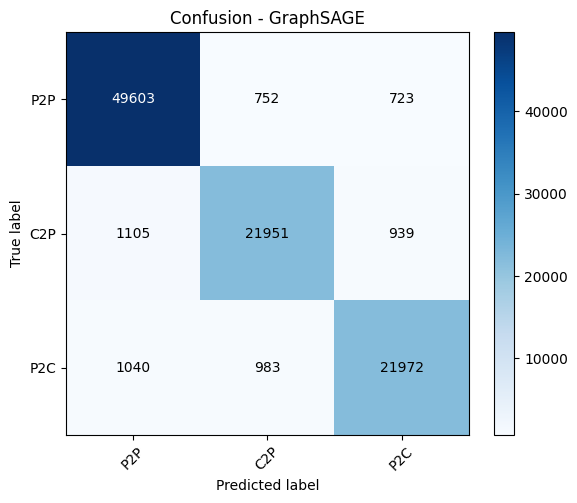

Normalized confusion matrix (%)


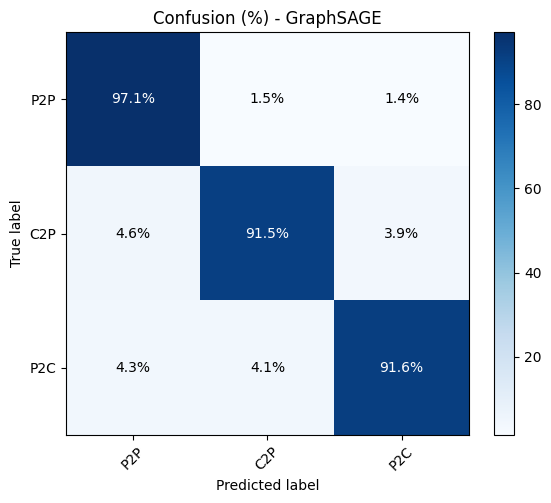

              precision    recall  f1-score   support

         P2P     0.9585    0.9711    0.9648     51078
         C2P     0.9267    0.9148    0.9207     23995
         P2C     0.9297    0.9157    0.9226     23995

    accuracy                         0.9441     99068
   macro avg     0.9383    0.9339    0.9361     99068
weighted avg     0.9439    0.9441    0.9439     99068

[BASELINE] Majority class=0 (P2P)
[BASELINE] Acc=51.56% | Macro-F1=22.68%
[MODEL]    Acc=94.41% | Macro-F1=93.61%
Recall per class (test):
  - P2P: 97.11%
  - C2P: 91.48%
  - P2C: 91.57%


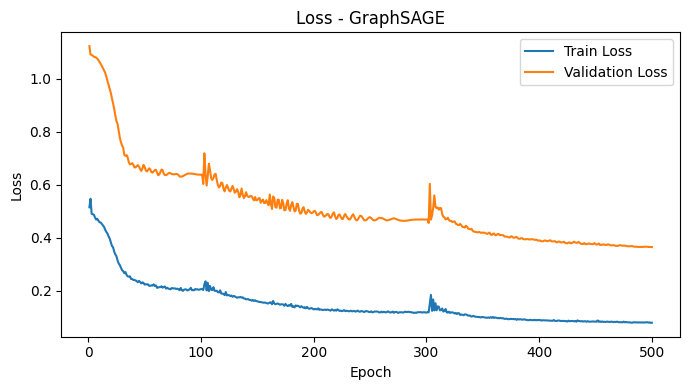

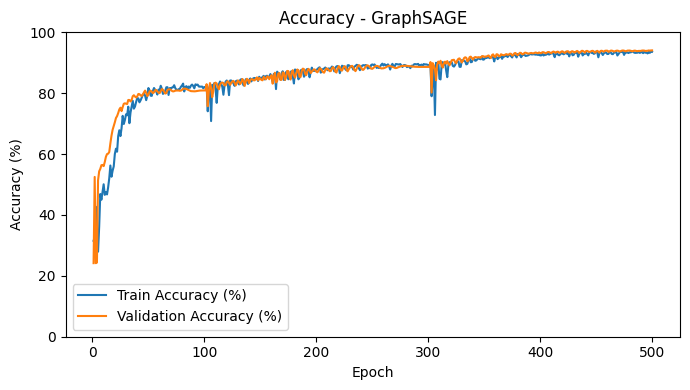

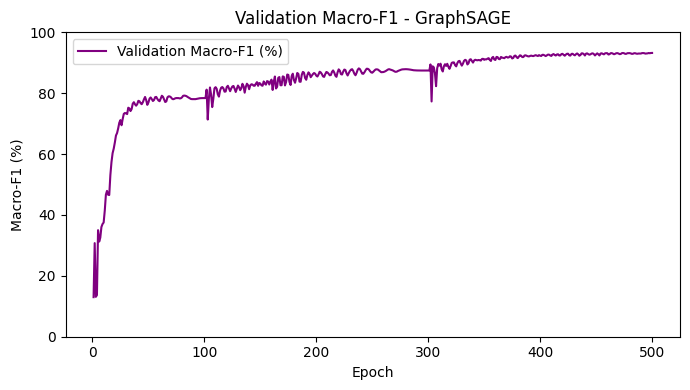


[OVERFITTING CHECK]
  Train acc final : 93.63%
  Val   acc final : 94.07%
  Gap             : -0.44%  ✓ OK
  Best val macro-F1 : 93.23%
  Test macro-F1     : 93.61%
  Diferencia        : 0.38%  ✓ OK

  Acc sobre train (etiquetas reales)   : 94.44%
  Acc sobre train (etiquetas mezcladas): 38.37%
  Azar esperado                        : 33.3%
  ⚠ Posible memorización

=== Training GAT (MLP Decoder) ===


In [ ]:
import torch
import torch.nn.functional as F
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
)
import matplotlib.pyplot as plt

# Global parameters (use unified config)
in_feats  = gnn.dgl_graph.ndata["feat"].shape[1]
device    = "cuda" if torch.cuda.is_available() else "cpu"
lr        = GLOBAL_CONFIG['lr']
patience  = GLOBAL_CONFIG['patience']
num_epochs = GLOBAL_CONFIG['epochs']

# Data and masks
g       = gnn.dgl_graph.to(device)
feat    = g.ndata["feat"].to(device)

# Degree features para forzar la asimetría C2P vs P2C en el decoder
# g.ndata["log_out_deg"] = torch.log1p(g.out_degrees().float()).to(device)
# g.ndata["log_in_deg"]  = torch.log1p(g.in_degrees().float()).to(device)
label_key = next((k for k in ["label", "relationship", "Relationship"] if k in g.edata), None)
if label_key is None:
    raise KeyError(f"Label column not found in edata. Available keys: {list(g.edata.keys())}")

labels  = g.edata[label_key].long().to(device)
train_m = g.edata["train_mask"].bool().to(device)
val_m   = g.edata["val_mask"].bool().to(device) if "val_mask" in g.edata else None
test_m  = g.edata["test_mask"].bool().to(device)

if val_m is None or val_m.sum().item() == 0:
    raise ValueError("val_mask is empty/not found. Use split_edges_classification with val_size > 0.")

labeled_m = train_m | val_m | test_m
n_classes = int(labels[labeled_m].max().item()) + 1

class_counts = torch.bincount(labels[train_m], minlength=n_classes).float()
class_weights = (class_counts.sum() / (n_classes * class_counts.clamp(min=1.0))).to(device)

default_names = ["P2P", "C2P", "P2C"]
class_names = default_names[:n_classes] if n_classes <= len(default_names) else [f"Class {i}" for i in range(n_classes)]

for name, Model in models.items():
    print(f"\n=== Training {name} (MLP Decoder) ===")


    extra_kw = {'num_heads': GLOBAL_CONFIG['num_heads']} if 'GAT' in name else {}
    model = Model(in_feats,
                  GLOBAL_CONFIG['hidden_dim'],
                  GLOBAL_CONFIG['out_dim'],
                  out_feats_mlp=n_classes,
                  edge_dim=1,
                  drop=GLOBAL_CONFIG['dropout'],
                  **extra_kw).to(device)
    
    opt   = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=GLOBAL_CONFIG['weight_decay'])

    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(opt, T_0=100, T_mult=2)

    hist = {"loss_tr": [], "acc_tr": [], "loss_val": [], "acc_val": [], "f1_val": []}
    best_macro_f1, best_loss, wait, best_w = -1.0, float("inf"), 0, None

    t0 = time.perf_counter()
    for ep in range(1, GLOBAL_CONFIG['epochs'] + 1):
        model.train()
        h = model.encode(g, feat)
        logits = model.decodeMLP(g, h)

        loss = focal_loss(logits[train_m], labels[train_m],
                          alpha=class_weights,
                          gamma=GLOBAL_CONFIG['focal_gamma'])
        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GLOBAL_CONFIG['grad_clip'])
        opt.step()
        scheduler.step(ep - 1 + (1 / num_epochs))

        with torch.no_grad():
            preds_tr = logits[train_m].argmax(1)
            acc_tr = (preds_tr == labels[train_m]).float().mean().item()

        model.eval()
        with torch.no_grad():
            logits_t = model.decodeMLP(g, model.encode(g, feat))

            loss_val = F.cross_entropy(logits_t[val_m], 
                                       labels[val_m], 
                                       weight=class_weights)
            
            # loss_val = F.cross_entropy(logits_t[val_m], 
            #                            labels[val_m])

            preds_val = logits_t[val_m].argmax(1)
            val_true = labels[val_m]
            acc_val = (preds_val == val_true).float().mean().item()
            macro_f1_val = f1_score(
                val_true.cpu().numpy(),
                preds_val.cpu().numpy(),
                average="macro",
                zero_division=0,
            )

        hist["loss_tr"].append(loss.item())
        hist["acc_tr"].append(acc_tr * 100)
        hist["loss_val"].append(loss_val.item())
        hist["acc_val"].append(acc_val * 100)
        hist["f1_val"].append(macro_f1_val * 100)

        improved_f1 = macro_f1_val > (best_macro_f1 + 1e-4)
        tie_break_loss = abs(macro_f1_val - best_macro_f1) <= 1e-4 and loss_val.item() < (best_loss - 1e-4)

        if improved_f1 or tie_break_loss:
            best_macro_f1, best_loss, wait = macro_f1_val, loss_val.item(), 0
            best_w = model.state_dict()
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stop at epoch {ep} (best val macro-F1={best_macro_f1*100:.2f}%)")
                break

        if ep % 10 == 0 or ep == 1:
            print(
                f"ep{ep:03d} | loss_tr {loss:.4f} acc_tr {acc_tr:.2%} | "
                f"loss_val {loss_val:.4f} acc_val {acc_val:.2%} f1_val {macro_f1_val:.2%}"
            )

    tiempo_total = time.perf_counter() - t0
    mins, secs = divmod(tiempo_total, 60)
    print(f"\n{'='*50}")
    print(f"[TIEMPO] {name} (MLP): {int(mins)}m {secs:.1f}s  ({tiempo_total:.1f}s total)")
    print(f"{'='*50}")

    if best_w is not None:
        model.load_state_dict(best_w)

    with torch.no_grad():
        logits_best = model.decodeMLP(g, model.encode(g, feat))
        preds_best = logits_best[test_m].argmax(1).cpu()
        truth = labels[test_m].cpu()

    cm = confusion_matrix(truth, preds_best, labels=list(range(n_classes)))
    plot_confusion_matrix_2(cm, class_names, False, title=f"Confusion - {name}")
    plot_confusion_matrix_2(cm, class_names, True, title=f"Confusion (%) - {name}")

    print(classification_report(truth, preds_best, digits=4, zero_division=0, target_names=class_names))

    majority_class = int(torch.mode(labels[train_m]).values.item())
    baseline_preds = torch.full_like(truth, fill_value=majority_class)
    baseline_acc = accuracy_score(truth, baseline_preds) * 100
    baseline_f1_macro = f1_score(truth, baseline_preds, average="macro", zero_division=0) * 100

    recalls_per_class = recall_score(
        truth,
        preds_best,
        average=None,
        labels=list(range(n_classes)),
        zero_division=0,
    )

    model_acc = accuracy_score(truth, preds_best) * 100
    model_f1_macro = f1_score(truth, preds_best, average="macro", zero_division=0) * 100

    print(f"[BASELINE] Majority class={majority_class} ({class_names[majority_class] if majority_class < len(class_names) else majority_class})")
    print(f"[BASELINE] Acc={baseline_acc:.2f}% | Macro-F1={baseline_f1_macro:.2f}%")
    print(f"[MODEL]    Acc={model_acc:.2f}% | Macro-F1={model_f1_macro:.2f}%")

    print("Recall per class (test):")
    for i, r in enumerate(recalls_per_class):
        cname = class_names[i] if i < len(class_names) else f"Class {i}"
        print(f"  - {cname}: {r*100:.2f}%")

    epochs_done = range(1, len(hist["loss_tr"]) + 1)

    plt.figure(figsize=(7, 4))
    plt.plot(epochs_done, hist["loss_tr"], label="Train Loss")
    plt.plot(epochs_done, hist["loss_val"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Loss - {name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(epochs_done, hist["acc_tr"], label="Train Accuracy (%)")
    plt.plot(epochs_done, hist["acc_val"], label="Validation Accuracy (%)")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.ylim(0, 100)
    plt.title(f"Accuracy - {name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(epochs_done, hist["f1_val"], label="Validation Macro-F1 (%)", color="purple")
    plt.xlabel("Epoch")
    plt.ylabel("Macro-F1 (%)")
    plt.ylim(0, 100)
    plt.title(f"Validation Macro-F1 - {name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ── Overfitting check ─────────────────────────────────────────────
    print("\n[OVERFITTING CHECK]")

    # 1. Gap train vs val (al final del entrenamiento)
    final_acc_tr  = hist["acc_tr"][-1]
    final_acc_val = hist["acc_val"][-1]
    gap = final_acc_tr - final_acc_val
    print(f"  Train acc final : {final_acc_tr:.2f}%")
    print(f"  Val   acc final : {final_acc_val:.2f}%")
    print(f"  Gap             : {gap:.2f}%  {'⚠ posible overfitting' if gap > 10 else '✓ OK'}")

    # 2. Val F1 vs Test F1 (deben ser cercanos si el split es representativo)
    f1_gap = abs(best_macro_f1 * 100 - model_f1_macro)
    print(f"  Best val macro-F1 : {best_macro_f1*100:.2f}%")
    print(f"  Test macro-F1     : {model_f1_macro:.2f}%")
    print(f"  Diferencia        : {f1_gap:.2f}%  {'⚠ split sospechoso' if f1_gap > 5 else '✓ OK'}")

    # 3. Sanity check: predicción con etiquetas mezcladas en train
    # Si el modelo aprendió patrones reales, al mezclar las etiquetas del
    # train set y re-evaluar sobre esas mismas aristas, el score debe caer
    # cerca del azar (~33% para 3 clases).
    with torch.no_grad():
        logits_tr = model.decodeMLP(g, model.encode(g, feat))
        preds_tr_final = logits_tr[train_m].argmax(1).cpu()
        real_labels_tr = labels[train_m].cpu()
        shuffled_labels_tr = real_labels_tr[torch.randperm(len(real_labels_tr))]

    acc_real     = accuracy_score(real_labels_tr, preds_tr_final)
    acc_shuffled = accuracy_score(shuffled_labels_tr, preds_tr_final)
    expected_random = 1.0 / n_classes
    print(f"\n  Acc sobre train (etiquetas reales)   : {acc_real*100:.2f}%")
    print(f"  Acc sobre train (etiquetas mezcladas): {acc_shuffled*100:.2f}%")
    print(f"  Azar esperado                        : {expected_random*100:.1f}%")
    print(f"  {'✓ El modelo usa patrones reales' if acc_shuffled < expected_random + 0.05 else '⚠ Posible memorización'}")



## Caso 1: Se utiliza grafo con atributos de centralidad

In [ ]:
# 1. Load data with the new format (node_id/asn + src_id/dst_id/relationship)
gnn = GNN(debug=True)
gnn.load_dataset_only_cntrality_attr(str(nodes_file), str(edges_file))

gnn.split_edges_classification(
    train_size=0.8,
    val_size=0.15,
    seed=42,
    balance_mode="strict_equal",   # use "proportional" to keep natural class distribution
)

g0 = gnn.dgl_graph
print("\n[Loaded graph summary]")
print(f"- Nodes: {g0.num_nodes():,}")
print(f"- Edges: {g0.num_edges():,}")
print(f"- Feature dimension: {g0.ndata['feat'].shape[1]}")
print(f"- Edge data keys: {list(g0.edata.keys())}")
print(f"- Train edges: {g0.edata['train_mask'].sum().item():,}")
print(f"- Validation edges: {g0.edata['val_mask'].sum().item():,}")
print(f"- Test edges: {g0.edata['test_mask'].sum().item():,}")

if "label" in g0.edata:
    print(f"- Global label distribution: {Counter(g0.edata['label'].tolist())}")
    tr = g0.edata['label'][g0.edata['train_mask']]
    va = g0.edata['label'][g0.edata['val_mask']]
    te = g0.edata['label'][g0.edata['test_mask']]
    print(f"- Train distribution: {Counter(tr.tolist())}")
    print(f"- Validation distribution: {Counter(va.tolist())}")
    print(f"- Test distribution: {Counter(te.tolist())}")


Grafo cargado: 79504 nodos, 807496 aristas
Aristas en ambos sentidos: True
Features usadas (5): ['weight', 'PageRank', 'degree_centrality', 'betweenness_centrality', 'eigenvector_centrality']
Dimensión de entrada (in_feats): 5
Edge features: 1 dim

[SPLIT COMPLETO - ESTRATIFICADO]
Modo balanceo: strict_equal
Etiqueta usada: label
Total aristas etiquetadas: 660438
Train: 383910 | Val: 71982 | Test: 23997
Distribución Train: {1: 127970, 0: 127970, 2: 127970}
Distribución Val:   {0: 23994, 2: 23994, 1: 23994}
Distribución Test:  {2: 7999, 1: 7999, 0: 7999}

[Loaded graph summary]
- Nodes: 79,504
- Edges: 807,496
- Feature dimension: 5
- Edge data keys: ['label', 'edge_feat', 'train_mask', 'val_mask', 'test_mask']
- Train edges: 383,910
- Validation edges: 71,982
- Test edges: 23,997
- Global label distribution: Counter({0: 340512, 1: 159963, 2: 159963, -1: 147058})
- Train distribution: Counter({1: 127970, 2: 127970, 0: 127970})
- Validation distribution: Counter({1: 23994, 0: 23994, 2: 2

In [ ]:
# Modelos a entrenar
models = {
    # 'GCN': GCN3L,
    'GraphSAGE': GraphSAGE3L,
    'GAT': GAT3L,
}

# models = {
#     'GCN': GCN2L,
#     'GraphSAGE': GraphSAGE2L,
#     'GAT': GAT2L,
# }



models_dict = models  # alias por compatibilidad

### Decode: DotProduct

In [ ]:
# 1.- Definición parámetros (usar config global)
# ----------------------------------------------
in_feats      = gnn.dgl_graph.ndata["feat"].shape[1]
hidden_feats  = GLOBAL_CONFIG['hidden_dim']
emb_dim       = GLOBAL_CONFIG['out_dim']
lr            = GLOBAL_CONFIG['lr']
device        = "cuda" if torch.cuda.is_available() else "cpu"

# 2.- Datos y máscaras
# ----------------------------------------------
g       = gnn.dgl_graph.to(device)
feat    = g.ndata["feat"].to(device)

Using device: cpu
Using edge label key: label
Number of classes detected: 3
Train class counts: [127970.0, 127970.0, 127970.0]
Class weights: [1.0, 1.0, 1.0]

Training GCN (Bilinear)
----------------------------------------
ep001 | loss_tr 1.1782 acc_tr 35.67% | loss_val 1.1110 acc_val 43.73% f1_val 42.07%
ep010 | loss_tr 0.9503 acc_tr 61.26% | loss_val 0.9049 acc_val 63.07% f1_val 61.51%
ep020 | loss_tr 0.8554 acc_tr 62.70% | loss_val 0.7911 acc_val 63.31% f1_val 61.84%
ep030 | loss_tr 0.8056 acc_tr 64.51% | loss_val 0.7417 acc_val 65.53% f1_val 65.80%
ep040 | loss_tr 0.7921 acc_tr 66.45% | loss_val 0.7228 acc_val 67.65% f1_val 68.16%
ep050 | loss_tr 0.7850 acc_tr 67.17% | loss_val 0.7190 acc_val 67.98% f1_val 68.45%
ep060 | loss_tr 0.7338 acc_tr 73.00% | loss_val 0.6493 acc_val 74.46% f1_val 74.84%
ep070 | loss_tr 0.6806 acc_tr 79.13% | loss_val 0.5846 acc_val 80.37% f1_val 80.50%
ep080 | loss_tr 0.6332 acc_tr 83.75% | loss_val 0.5295 acc_val 84.55% f1_val 84.56%
ep090 | loss_tr 0.60

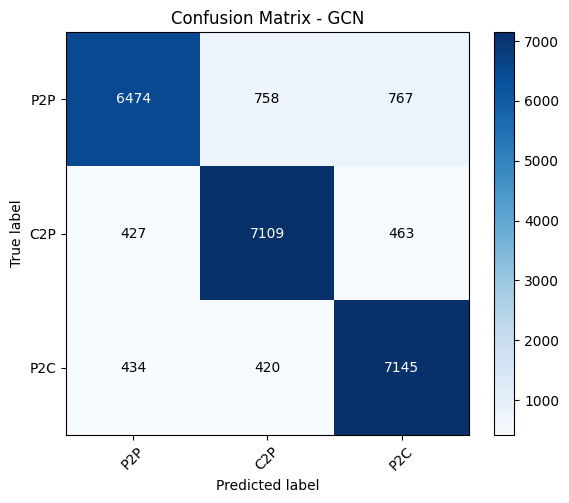

Normalized confusion matrix (%)


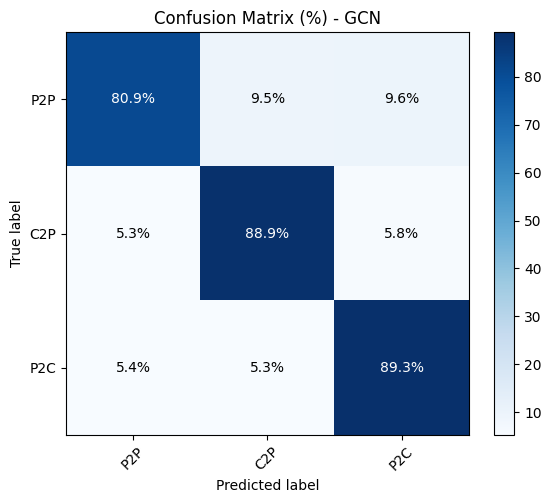

              precision    recall  f1-score   support

         P2P     0.8826    0.8094    0.8444      7999
         C2P     0.8578    0.8887    0.8730      7999
         P2C     0.8531    0.8932    0.8727      7999

    accuracy                         0.8638     23997
   macro avg     0.8645    0.8638    0.8634     23997
weighted avg     0.8645    0.8638    0.8634     23997

[BASELINE] Majority class=0 (P2P)
[BASELINE] Acc=33.33% | Macro-F1=16.67%
[MODEL]    Acc=86.38% | Macro-F1=86.34%
[TEST] micro:    Prec=86.38%  Rec=86.38%  F1=86.38% | Acc=86.38%
[TEST] macro:    Prec=86.45%  Rec=86.38%  F1=86.34%
[TEST] weighted: Prec=86.45%  Rec=86.38%  F1=86.34%
Recall per class (test):
  - P2P: 80.94%
  - C2P: 88.87%
  - P2C: 89.32%


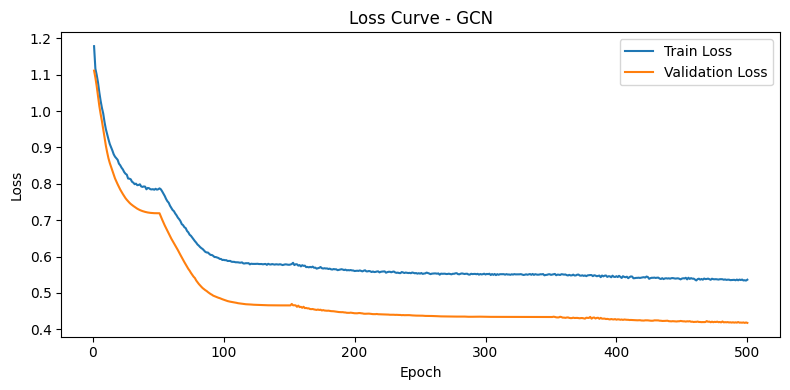

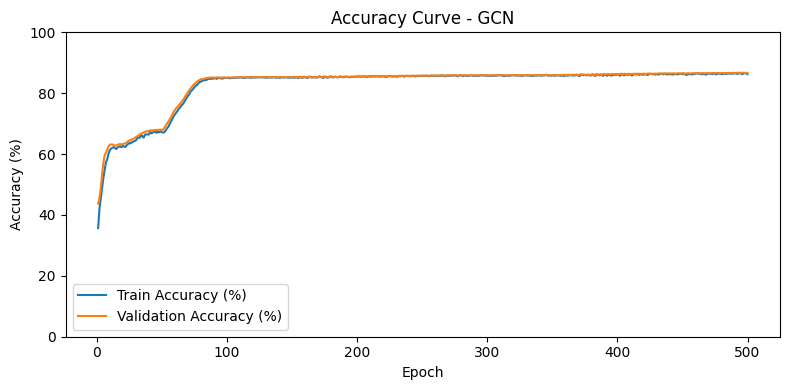

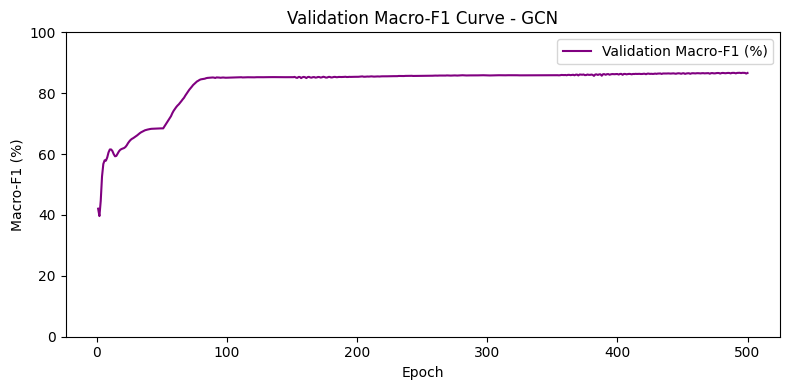

Inference file saved at: results/end_to_end/predictions/inference_results_GCN_rib_20260301_0000_to_20260302_0000_enriched_tesis_bilinear.txt

Training GraphSAGE (Bilinear)
----------------------------------------
ep001 | loss_tr 18.6814 acc_tr 32.04% | loss_val 8.8885 acc_val 34.23% f1_val 33.93%
ep010 | loss_tr 8.6916 acc_tr 39.20% | loss_val 3.6199 acc_val 49.37% f1_val 49.11%
ep020 | loss_tr 5.4646 acc_tr 44.36% | loss_val 1.9286 acc_val 55.20% f1_val 54.76%
ep030 | loss_tr 4.3802 acc_tr 45.33% | loss_val 1.5575 acc_val 59.38% f1_val 59.29%
ep040 | loss_tr 3.9117 acc_tr 47.01% | loss_val 1.4785 acc_val 60.48% f1_val 60.54%
ep050 | loss_tr 3.9847 acc_tr 46.98% | loss_val 1.4585 acc_val 60.83% f1_val 60.91%
ep060 | loss_tr 3.1896 acc_tr 47.03% | loss_val 1.2562 acc_val 63.85% f1_val 64.00%
ep070 | loss_tr 2.5789 acc_tr 49.75% | loss_val 1.1427 acc_val 65.82% f1_val 65.90%
ep080 | loss_tr 2.2173 acc_tr 52.13% | loss_val 1.0078 acc_val 68.42% f1_val 68.57%
ep090 | loss_tr 1.9336 acc_tr 

In [ ]:

label_key = next((k for k in ["label", "relationship", "Relationship"] if k in g.edata), None)
if label_key is None:
    raise KeyError(f"Label column not found in edata. Available keys: {list(g.edata.keys())}")
labels = g.edata[label_key].long().to(device)

train_m = g.edata["train_mask"].bool().to(device)
val_m   = g.edata["val_mask"].bool().to(device) if "val_mask" in g.edata else None
test_m  = g.edata["test_mask"].bool().to(device)

if train_m.sum().item() == 0 or test_m.sum().item() == 0:
    raise ValueError("train_mask/test_mask are empty. Check split_edges_classification().")
if val_m is None or val_m.sum().item() == 0:
    raise ValueError("val_mask is empty/not found. Use split_edges_classification with val_size > 0.")

labeled_m = train_m | val_m | test_m
n_classes = int(labels[labeled_m].max().item()) + 1

# Class weights to reduce collapse into a dominant class
class_counts = torch.bincount(labels[train_m], minlength=n_classes).float()
class_weights = (class_counts.sum() / (n_classes * class_counts.clamp(min=1.0))).to(device)

default_names = ["P2P", "C2P", "P2C"]
class_names = default_names[:n_classes] if n_classes <= len(default_names) else [f"Class {i}" for i in range(n_classes)]

print(f"Using device: {device}")
print(f"Using edge label key: {label_key}")
print(f"Number of classes detected: {n_classes}")
print(f"Train class counts: {class_counts.tolist()}")
print(f"Class weights: {class_weights.tolist()}")

# 3.- Load node_id -> asn mapping for readable inference export
id_to_asn = {}
with open(nodes_file, newline="") as f:
    reader = csv.DictReader(f)
    for row in reader:
        id_to_asn[int(row["node_id"])] = int(row["asn"])

# 4.- Output directories
output_root = Path("./results/end_to_end")
plot_dir = output_root / "plots"
pred_dir = output_root / "predictions"
plot_dir.mkdir(parents=True, exist_ok=True)
pred_dir.mkdir(parents=True, exist_ok=True)
run_tag = edges_file.stem.replace("edges_", "")

# 5.- Training per model (Bilinear Decoder)
for name, Model in models.items():
    print(f"\nTraining {name} (Bilinear)\n" + "-" * 40)

    history = {"loss_tr": [], "acc_tr": [], "loss_val": [], "acc_val": [], "f1_val": []}
    extra_kw = {'num_heads': GLOBAL_CONFIG['num_heads']} if 'GAT' in name else {}
    model = Model(in_feats,
                  GLOBAL_CONFIG['hidden_dim'],
                  GLOBAL_CONFIG['out_dim'],
                  out_feats_mlp=n_classes,
                  drop=GLOBAL_CONFIG['dropout'],
                  **extra_kw).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=GLOBAL_CONFIG['lr'], weight_decay=GLOBAL_CONFIG['weight_decay'])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(opt, T_0=50, T_mult=2)

    best_macro_f1, best_val_loss, wait, best_w = -1.0, float("inf"), 0, None

    t0 = time.perf_counter()
    for epoch in range(1, GLOBAL_CONFIG['epochs'] + 1):
        model.train()
        h = model.encode(g, feat)
        logits = model.decodeBilinear(g, h)

        loss = F.cross_entropy(logits[train_m], labels[train_m],
                               weight=class_weights, label_smoothing=GLOBAL_CONFIG['label_smooth'])
        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GLOBAL_CONFIG['grad_clip'])
        opt.step()
        scheduler.step(epoch - 1 + (1 / GLOBAL_CONFIG['epochs']))

        with torch.no_grad():
            preds_tr = logits[train_m].argmax(1)
            acc_tr = (preds_tr == labels[train_m]).float().mean().item()

        model.eval()
        with torch.no_grad():
            logits_val = model.decodeBilinear(g, model.encode(g, feat))
            loss_val = F.cross_entropy(logits_val[val_m], labels[val_m], weight=class_weights)
            preds_val = logits_val[val_m].argmax(1)
            val_true = labels[val_m]
            acc_val = (preds_val == val_true).float().mean().item()
            macro_f1_val = f1_score(
                val_true.cpu().numpy(),
                preds_val.cpu().numpy(),
                average="macro",
                zero_division=0,
            )

        history["loss_tr"].append(loss.item())
        history["acc_tr"].append(acc_tr * 100)
        history["loss_val"].append(loss_val.item())
        history["acc_val"].append(acc_val * 100)
        history["f1_val"].append(macro_f1_val * 100)

        improved_f1 = macro_f1_val > (best_macro_f1 + 1e-4)
        tie_break_loss = abs(macro_f1_val - best_macro_f1) <= 1e-4 and loss_val.item() < (best_val_loss - 1e-4)

        if improved_f1 or tie_break_loss:
            best_macro_f1, best_val_loss, wait = macro_f1_val, loss_val.item(), 0
            best_w = model.state_dict()
        else:
            wait += 1
            if wait >= GLOBAL_CONFIG['patience']:
                print(f"Early stop at epoch {epoch} (best val macro-F1={best_macro_f1*100:.2f}%)")
                break

        if epoch % 10 == 0 or epoch == 1:
            print(
                f"ep{epoch:03d} | loss_tr {loss:.4f} acc_tr {acc_tr:.2%} | "
                f"loss_val {loss_val:.4f} acc_val {acc_val:.2%} f1_val {macro_f1_val:.2%}"
            )

    tiempo_total = time.perf_counter() - t0
    mins, secs = divmod(tiempo_total, 60)
    print(f"\n{'='*50}")
    print(f"[TIEMPO] {name} (Bilinear): {int(mins)}m {secs:.1f}s  ({tiempo_total:.1f}s total)")
    print(f"{'='*50}")

    if best_w is not None:
        model.load_state_dict(best_w)

    with torch.no_grad():
        logits_best = model.decodeBilinear(g, model.encode(g, feat))
        preds_best = logits_best[test_m].argmax(1).cpu()
        truth = labels[test_m].cpu()

    cm = confusion_matrix(truth, preds_best, labels=list(range(n_classes)))
    plot_confusion_matrix_2(cm, classes=class_names, normalize=False, title=f"Confusion Matrix - {name}")
    plot_confusion_matrix_2(cm, classes=class_names, normalize=True, title=f"Confusion Matrix (%) - {name}")

    print(classification_report(truth, preds_best, digits=4, zero_division=0, target_names=class_names))

    # Baseline: always predict the majority train class
    majority_class = int(torch.mode(labels[train_m]).values.item())
    baseline_preds = torch.full_like(truth, fill_value=majority_class)
    baseline_acc = accuracy_score(truth, baseline_preds) * 100
    baseline_f1_macro = f1_score(truth, baseline_preds, average="macro", zero_division=0) * 100

    prec_micro = precision_score(truth, preds_best, average="micro", zero_division=0) * 100
    rec_micro  = recall_score(truth, preds_best, average="micro", zero_division=0) * 100
    f1_micro   = f1_score(truth, preds_best, average="micro", zero_division=0) * 100
    acc        = accuracy_score(truth, preds_best) * 100

    prec_macro = precision_score(truth, preds_best, average="macro", zero_division=0) * 100
    rec_macro  = recall_score(truth, preds_best, average="macro", zero_division=0) * 100
    f1_macro   = f1_score(truth, preds_best, average="macro", zero_division=0) * 100

    prec_w = precision_score(truth, preds_best, average="weighted", zero_division=0) * 100
    rec_w  = recall_score(truth, preds_best, average="weighted", zero_division=0) * 100
    f1_w   = f1_score(truth, preds_best, average="weighted", zero_division=0) * 100

    recalls_per_class = recall_score(
        truth,
        preds_best,
        average=None,
        labels=list(range(n_classes)),
        zero_division=0,
    )

    print(f"[BASELINE] Majority class={majority_class} ({class_names[majority_class] if majority_class < len(class_names) else majority_class})")
    print(f"[BASELINE] Acc={baseline_acc:.2f}% | Macro-F1={baseline_f1_macro:.2f}%")
    print(f"[MODEL]    Acc={acc:.2f}% | Macro-F1={f1_macro:.2f}%")
    print(f"[TEST] micro:    Prec={prec_micro:.2f}%  Rec={rec_micro:.2f}%  F1={f1_micro:.2f}% | Acc={acc:.2f}%")
    print(f"[TEST] macro:    Prec={prec_macro:.2f}%  Rec={rec_macro:.2f}%  F1={f1_macro:.2f}%")
    print(f"[TEST] weighted: Prec={prec_w:.2f}%  Rec={rec_w:.2f}%  F1={f1_w:.2f}%")

    print("Recall per class (test):")
    for i, r in enumerate(recalls_per_class):
        cname = class_names[i] if i < len(class_names) else f"Class {i}"
        print(f"  - {cname}: {r*100:.2f}%")

    epoch_axis = range(1, len(history["loss_tr"]) + 1)

    plt.figure(figsize=(8, 4))
    plt.plot(epoch_axis, history["loss_tr"], label="Train Loss")
    plt.plot(epoch_axis, history["loss_val"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Loss Curve - {name}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(plot_dir / f"loss_{name}_{run_tag}_bilinear.png", dpi=300, bbox_inches='tight')
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(epoch_axis, history["acc_tr"], label="Train Accuracy (%)")
    plt.plot(epoch_axis, history["acc_val"], label="Validation Accuracy (%)")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title(f"Accuracy Curve - {name}")
    plt.ylim(0, 100)
    plt.legend()
    plt.tight_layout()
    plt.savefig(plot_dir / f"accuracy_{name}_{run_tag}_bilinear.png", dpi=300, bbox_inches='tight')
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(epoch_axis, history["f1_val"], label="Validation Macro-F1 (%)", color="purple")
    plt.xlabel("Epoch")
    plt.ylabel("Macro-F1 (%)")
    plt.title(f"Validation Macro-F1 Curve - {name}")
    plt.ylim(0, 100)
    plt.legend()
    plt.tight_layout()
    plt.savefig(plot_dir / f"macrof1_val_{name}_{run_tag}_bilinear.png", dpi=300, bbox_inches='tight')
    plt.show()

    out_file = pred_dir / f"inference_results_{name}_{run_tag}_bilinear.txt"
    u, v = g.edges()
    test_eids = torch.where(test_m)[0].cpu().tolist()
    with open(out_file, "w") as f:
        f.write("src_id|dst_id|src_asn|dst_asn|pred|real\n")
        for i, eidx in enumerate(test_eids):
            src_id = int(u[eidx].item())
            dst_id = int(v[eidx].item())
            src_asn = id_to_asn.get(src_id, -1)
            dst_asn = id_to_asn.get(dst_id, -1)
            pred = int(preds_best[i].item())
            real = int(truth[i].item())
            f.write(f"{src_id}|{dst_id}|{src_asn}|{dst_asn}|{pred}|{real}\n")

    print(f"Inference file saved at: {out_file}")

# ── Overfitting check ─────────────────────────────────────────────
print("\n[OVERFITTING CHECK]")

# 1. Gap train vs val (al final del entrenamiento)
final_acc_tr  = hist["acc_tr"][-1]
final_acc_val = hist["acc_val"][-1]
gap = final_acc_tr - final_acc_val
print(f"  Train acc final : {final_acc_tr:.2f}%")
print(f"  Val   acc final : {final_acc_val:.2f}%")
print(f"  Gap             : {gap:.2f}%  {'⚠ posible overfitting' if gap > 10 else '✓ OK'}")

# 2. Val F1 vs Test F1 (deben ser cercanos si el split es representativo)
f1_gap = abs(best_macro_f1 * 100 - model_f1_macro)
print(f"  Best val macro-F1 : {best_macro_f1*100:.2f}%")
print(f"  Test macro-F1     : {model_f1_macro:.2f}%")
print(f"  Diferencia        : {f1_gap:.2f}%  {'⚠ split sospechoso' if f1_gap > 5 else '✓ OK'}")

# 3. Sanity check: predicción con etiquetas mezcladas en train
# Si el modelo aprendió patrones reales, al mezclar las etiquetas del
# train set y re-evaluar sobre esas mismas aristas, el score debe caer
# cerca del azar (~33% para 3 clases).
with torch.no_grad():
    logits_tr = model.decodeMLP(g, model.encode(g, feat))
    preds_tr_final = logits_tr[train_m].argmax(1).cpu()
    real_labels_tr = labels[train_m].cpu()
    shuffled_labels_tr = real_labels_tr[torch.randperm(len(real_labels_tr))]

acc_real     = accuracy_score(real_labels_tr, preds_tr_final)
acc_shuffled = accuracy_score(shuffled_labels_tr, preds_tr_final)
expected_random = 1.0 / n_classes
print(f"\n  Acc sobre train (etiquetas reales)   : {acc_real*100:.2f}%")
print(f"  Acc sobre train (etiquetas mezcladas): {acc_shuffled*100:.2f}%")
print(f"  Azar esperado                        : {expected_random*100:.1f}%")
print(f"  {'✓ El modelo usa patrones reales' if acc_shuffled < expected_random + 0.05 else '⚠ Posible memorización'}")


### Decode: MLP

In [ ]:
import torch
import torch.nn.functional as F
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
)
import matplotlib.pyplot as plt

# Global parameters (use unified config)
in_feats  = gnn.dgl_graph.ndata["feat"].shape[1]
device    = "cuda" if torch.cuda.is_available() else "cpu"
lr        = GLOBAL_CONFIG['lr']
patience  = GLOBAL_CONFIG['patience']

# Data and masks
g       = gnn.dgl_graph.to(device)
feat    = g.ndata["feat"].to(device)

label_key = next((k for k in ["label", "relationship", "Relationship"] if k in g.edata), None)
if label_key is None:
    raise KeyError(f"Label column not found in edata. Available keys: {list(g.edata.keys())}")

labels  = g.edata[label_key].long().to(device)
train_m = g.edata["train_mask"].bool().to(device)
val_m   = g.edata["val_mask"].bool().to(device) if "val_mask" in g.edata else None
test_m  = g.edata["test_mask"].bool().to(device)

if val_m is None or val_m.sum().item() == 0:
    raise ValueError("val_mask is empty/not found. Use split_edges_classification with val_size > 0.")

labeled_m = train_m | val_m | test_m
n_classes = int(labels[labeled_m].max().item()) + 1

class_counts = torch.bincount(labels[train_m], minlength=n_classes).float()
class_weights = (class_counts.sum() / (n_classes * class_counts.clamp(min=1.0))).to(device)

default_names = ["P2P", "C2P", "P2C"]
class_names = default_names[:n_classes] if n_classes <= len(default_names) else [f"Class {i}" for i in range(n_classes)]

for name, Model in models.items():
    print(f"\n=== Training {name} (MLP Decoder) ===")

    # model = Model(in_feats, 
    #               GLOBAL_CONFIG['hidden_dim'], 
    #               GLOBAL_CONFIG['out_dim'], 
    #               out_feats_mlp=n_classes
    #               ).to(device)


    extra_kw = {'num_heads': GLOBAL_CONFIG['num_heads']} if 'GAT' in name else {}
    model = Model(in_feats,
                  GLOBAL_CONFIG['hidden_dim'],
                  GLOBAL_CONFIG['out_dim'],
                  out_feats_mlp=n_classes,
                  edge_dim=1,
                  drop=GLOBAL_CONFIG['dropout'],
                  **extra_kw).to(device)

    opt = torch.optim.Adam(model.parameters(), lr=GLOBAL_CONFIG['lr'], weight_decay=GLOBAL_CONFIG['weight_decay'])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(opt, T_0=100, T_mult=2)

    hist = {"loss_tr": [], "acc_tr": [], "loss_val": [], "acc_val": [], "f1_val": []}
    best_macro_f1, best_loss, wait, best_w = -1.0, float("inf"), 0, None

    t0 = time.perf_counter()
    for ep in range(1, GLOBAL_CONFIG['epochs'] + 1):
        model.train()
        h = model.encode(g, feat)
        logits = model.decodeMLP(g, h)

        loss = focal_loss(logits[train_m], labels[train_m],
                          alpha=class_weights,
                          gamma=GLOBAL_CONFIG['focal_gamma'])
        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GLOBAL_CONFIG['grad_clip'])
        opt.step()
        scheduler.step(ep - 1 + (1 / GLOBAL_CONFIG['epochs']))

        with torch.no_grad():
            preds_tr = logits[train_m].argmax(1)
            acc_tr = (preds_tr == labels[train_m]).float().mean().item()

        model.eval()
        with torch.no_grad():
            logits_t = model.decodeMLP(g, model.encode(g, feat))
            loss_val = F.cross_entropy(logits_t[val_m], labels[val_m], weight=class_weights)
            preds_val = logits_t[val_m].argmax(1)
            val_true = labels[val_m]
            acc_val = (preds_val == val_true).float().mean().item()
            macro_f1_val = f1_score(
                val_true.cpu().numpy(),
                preds_val.cpu().numpy(),
                average="macro",
                zero_division=0,
            )

        hist["loss_tr"].append(loss.item())
        hist["acc_tr"].append(acc_tr * 100)
        hist["loss_val"].append(loss_val.item())
        hist["acc_val"].append(acc_val * 100)
        hist["f1_val"].append(macro_f1_val * 100)

        improved_f1 = macro_f1_val > (best_macro_f1 + 1e-4)
        tie_break_loss = abs(macro_f1_val - best_macro_f1) <= 1e-4 and loss_val.item() < (best_loss - 1e-4)

        if improved_f1 or tie_break_loss:
            best_macro_f1, best_loss, wait = macro_f1_val, loss_val.item(), 0
            best_w = model.state_dict()
        else:
            wait += 1
            if wait >= GLOBAL_CONFIG['patience']:
                print(f"Early stop at epoch {ep} (best val macro-F1={best_macro_f1*100:.2f}%)")
                break

        if ep % 10 == 0 or ep == 1:
            print(
                f"ep{ep:03d} | loss_tr {loss:.4f} acc_tr {acc_tr:.2%} | "
                f"loss_val {loss_val:.4f} acc_val {acc_val:.2%} f1_val {macro_f1_val:.2%}"
            )

    tiempo_total = time.perf_counter() - t0
    mins, secs = divmod(tiempo_total, 60)
    print(f"\n{'='*50}")
    print(f"[TIEMPO] {name} (MLP): {int(mins)}m {secs:.1f}s  ({tiempo_total:.1f}s total)")
    print(f"{'='*50}")

    if best_w is not None:
        model.load_state_dict(best_w)

    with torch.no_grad():
        logits_best = model.decodeMLP(g, model.encode(g, feat))
        preds_best = logits_best[test_m].argmax(1).cpu()
        truth = labels[test_m].cpu()

    cm = confusion_matrix(truth, preds_best, labels=list(range(n_classes)))
    plot_confusion_matrix_2(cm, class_names, False, title=f"Confusion - {name}")
    plot_confusion_matrix_2(cm, class_names, True, title=f"Confusion (%) - {name}")

    print(classification_report(truth, preds_best, digits=4, zero_division=0, target_names=class_names))

    majority_class = int(torch.mode(labels[train_m]).values.item())
    baseline_preds = torch.full_like(truth, fill_value=majority_class)
    baseline_acc = accuracy_score(truth, baseline_preds) * 100
    baseline_f1_macro = f1_score(truth, baseline_preds, average="macro", zero_division=0) * 100

    recalls_per_class = recall_score(
        truth,
        preds_best,
        average=None,
        labels=list(range(n_classes)),
        zero_division=0,
    )

    model_acc = accuracy_score(truth, preds_best) * 100
    model_f1_macro = f1_score(truth, preds_best, average="macro", zero_division=0) * 100

    print(f"[BASELINE] Majority class={majority_class} ({class_names[majority_class] if majority_class < len(class_names) else majority_class})")
    print(f"[BASELINE] Acc={baseline_acc:.2f}% | Macro-F1={baseline_f1_macro:.2f}%")
    print(f"[MODEL]    Acc={model_acc:.2f}% | Macro-F1={model_f1_macro:.2f}%")

    print("Recall per class (test):")
    for i, r in enumerate(recalls_per_class):
        cname = class_names[i] if i < len(class_names) else f"Class {i}"
        print(f"  - {cname}: {r*100:.2f}%")

    epochs_done = range(1, len(hist["loss_tr"]) + 1)

    plt.figure(figsize=(7, 4))
    plt.plot(epochs_done, hist["loss_tr"], label="Train Loss")
    plt.plot(epochs_done, hist["loss_val"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Loss - {name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(epochs_done, hist["acc_tr"], label="Train Accuracy (%)")
    plt.plot(epochs_done, hist["acc_val"], label="Validation Accuracy (%)")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.ylim(0, 100)
    plt.title(f"Accuracy - {name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(epochs_done, hist["f1_val"], label="Validation Macro-F1 (%)", color="purple")
    plt.xlabel("Epoch")
    plt.ylabel("Macro-F1 (%)")
    plt.ylim(0, 100)
    plt.title(f"Validation Macro-F1 - {name}")
    plt.legend()
    plt.tight_layout()
    plt.show()


    # ── Overfitting check ─────────────────────────────────────────────
    print("\n[OVERFITTING CHECK]")

    # 1. Gap train vs val (al final del entrenamiento)
    final_acc_tr  = hist["acc_tr"][-1]
    final_acc_val = hist["acc_val"][-1]
    gap = final_acc_tr - final_acc_val
    print(f"  Train acc final : {final_acc_tr:.2f}%")
    print(f"  Val   acc final : {final_acc_val:.2f}%")
    print(f"  Gap             : {gap:.2f}%  {'⚠ posible overfitting' if gap > 10 else '✓ OK'}")

    # 2. Val F1 vs Test F1 (deben ser cercanos si el split es representativo)
    f1_gap = abs(best_macro_f1 * 100 - model_f1_macro)
    print(f"  Best val macro-F1 : {best_macro_f1*100:.2f}%")
    print(f"  Test macro-F1     : {model_f1_macro:.2f}%")
    print(f"  Diferencia        : {f1_gap:.2f}%  {'⚠ split sospechoso' if f1_gap > 5 else '✓ OK'}")

    # 3. Sanity check: predicción con etiquetas mezcladas en train
    # Si el modelo aprendió patrones reales, al mezclar las etiquetas del
    # train set y re-evaluar sobre esas mismas aristas, el score debe caer
    # cerca del azar (~33% para 3 clases).
    with torch.no_grad():
        logits_tr = model.decodeMLP(g, model.encode(g, feat))
        preds_tr_final = logits_tr[train_m].argmax(1).cpu()
        real_labels_tr = labels[train_m].cpu()
        shuffled_labels_tr = real_labels_tr[torch.randperm(len(real_labels_tr))]

    acc_real     = accuracy_score(real_labels_tr, preds_tr_final)
    acc_shuffled = accuracy_score(shuffled_labels_tr, preds_tr_final)
    expected_random = 1.0 / n_classes
    print(f"\n  Acc sobre train (etiquetas reales)   : {acc_real*100:.2f}%")
    print(f"  Acc sobre train (etiquetas mezcladas): {acc_shuffled*100:.2f}%")
    print(f"  Azar esperado                        : {expected_random*100:.1f}%")
    print(f"  {'✓ El modelo usa patrones reales' if acc_shuffled < expected_random + 0.05 else '⚠ Posible memorización'}")


NameError: name 'gnn' is not defined

## Caso 2: Enfoque end-to-end utilizando grafo con atributos de PeeringDB y muestreo aleatorio de vecinos (Random Neighbour Sampling)

In [ ]:

from modules.gnn_models import (
    GCN2L,
    GraphSAGE2L,
    GAT2L,
    GCN3L,
    GraphSAGE3L,
    GAT3L,
    GCNSampler2L,
    GraphSAGESample2L,
    GATSample2L
)

models = {
    # "GCN-Sampler":  GCNSampler2L,
    "SAGE-Sampler": GraphSAGESample2L,
    "GAT-Sampler":  GATSample2L
}


N_NEIGHBORS = 15

In [ ]:
# Cargar grafo con todos los atributos de nodos
gnn = GNN(debug=True)
gnn.load_dataset(str(nodes_file), str(edges_file))

# Split estratificado sin fuga entre direcciones opuestas (store_eids=True por defecto)
gnn.split_edges_classification(
    train_size=0.8,
    val_size=0.15,
    seed=42,
    balance_mode="strict_equal",
)

g0 = gnn.dgl_graph
print("\n[Resumen del grafo]")
print(f"- Nodos:              {g0.num_nodes():,}")
print(f"- Aristas:            {g0.num_edges():,}")
print(f"- Dimension features: {g0.ndata['feat'].shape[1]}")
print(f"- Train edges:        {gnn.train_eids.shape[0]:,}")
print(f"- Val edges:          {gnn.val_eids.shape[0]:,}")
print(f"- Test edges:         {gnn.test_eids.shape[0]:,}")
labels = g0.edata['label']
print(f"- Distribucion train: {Counter(labels[gnn.train_eids].tolist())}")
print(f"- Distribucion val:   {Counter(labels[gnn.val_eids].tolist())}")
print(f"- Distribucion test:  {Counter(labels[gnn.test_eids].tolist())}")


Grafo cargado: 79504 nodos, 807496 aristas
Aristas en ambos sentidos: True
Dimensión de entrada (in_feats): 72
Edge features: 1 dim

[SPLIT COMPLETO - ESTRATIFICADO]
Modo balanceo: strict_equal
Etiqueta usada: label
Total aristas etiquetadas: 660438
Train: 383910 | Val: 71982 | Test: 23997
Distribución Train: {1: 127970, 0: 127970, 2: 127970}
Distribución Val:   {0: 23994, 2: 23994, 1: 23994}
Distribución Test:  {2: 7999, 1: 7999, 0: 7999}

[Resumen del grafo]
- Nodos:              79,504
- Aristas:            807,496
- Dimension features: 72
- Train edges:        383,910
- Val edges:          71,982
- Test edges:         23,997
- Distribucion train: Counter({1: 127970, 0: 127970, 2: 127970})
- Distribucion val:   Counter({0: 23994, 2: 23994, 1: 23994})
- Distribucion test:  Counter({2: 7999, 1: 7999, 0: 7999})


In [ ]:
device     = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 1024

# NeighborSampler: 2 capas, N_NEIGHBORS vecinos por capa
sampler = dgl.dataloading.NeighborSampler(
    [N_NEIGHBORS, N_NEIGHBORS],
    prefetch_node_feats=['feat']
)
edge_sampler = dgl.dataloading.as_edge_prediction_sampler(
    sampler,
    prefetch_labels=['label']
)

# DataLoaders sobre edge IDs (no node IDs)
train_loader = dgl.dataloading.DataLoader(
    gnn.dgl_graph, gnn.train_eids, edge_sampler,
    batch_size=BATCH_SIZE, shuffle=True,  drop_last=False, device=device)

val_loader = dgl.dataloading.DataLoader(
    gnn.dgl_graph, gnn.val_eids, edge_sampler,
    batch_size=BATCH_SIZE, shuffle=False, drop_last=False, device=device)

test_loader = dgl.dataloading.DataLoader(
    gnn.dgl_graph, gnn.test_eids, edge_sampler,
    batch_size=BATCH_SIZE, shuffle=False, drop_last=False, device=device)

print(f"Device:        {device}")
print(f"Batch size:    {BATCH_SIZE}  |  Fan-out: {[N_NEIGHBORS, N_NEIGHBORS]}")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")


Device:        cpu
Batch size:    1024  |  Fan-out: [15, 15]
Train batches: 375
Val batches:   71
Test batches:  24



===== Training SAGE-Sampler =====


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/dgl/dataloading/dataloader.py:1149: DGLWarning: Dataloader CPU affinity opt is not enabled, consider switching it on (see enable_cpu_affinity() or CPU best practices for DGL [https://docs.dgl.ai/tutorials/cpu/cpu_best_practises.html])
  dgl_warning(


Epoch 001:   0%|          | 0/375 [00:00<?, ?it/s]

ep001 | loss_tr 0.5782  acc_tr 76.35% | loss_val 0.3595  acc_val 87.02%


Epoch 002:   0%|          | 0/375 [00:00<?, ?it/s]

...

Epoch 012:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 013:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 014:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 015:   0%|          | 0/375 [00:00<?, ?it/s]

ep015 | loss_tr 0.2305  acc_tr 91.83% | loss_val 0.2431  acc_val 91.29%

[TIEMPO] SAGE-Sampler (NeighborSampling): 3m 52.4s  (232.4s total)
Confusion matrix (not normalized)


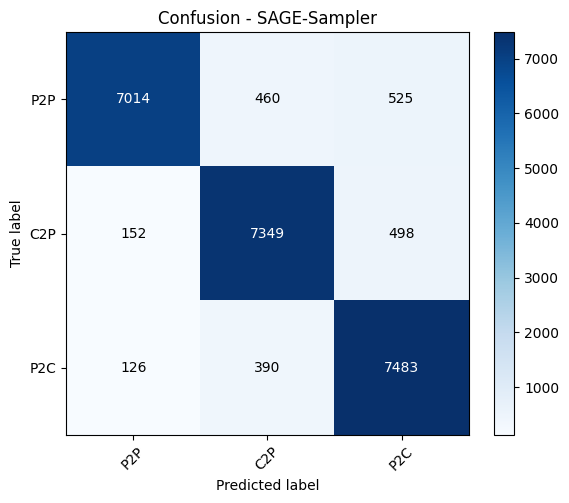

Normalized confusion matrix (%)


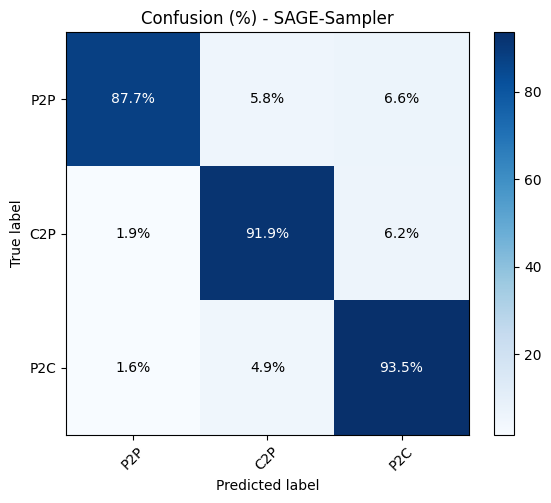

              precision    recall  f1-score   support

         P2P     0.9619    0.8769    0.9174      7999
         C2P     0.8963    0.9187    0.9074      7999
         P2C     0.8797    0.9355    0.9068      7999

    accuracy                         0.9104     23997
   macro avg     0.9126    0.9104    0.9105     23997
weighted avg     0.9126    0.9104    0.9105     23997



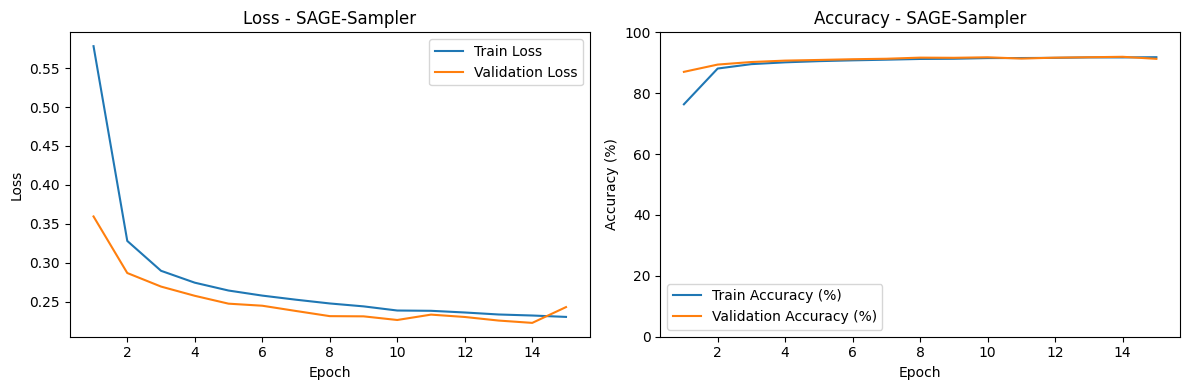


===== Training GAT-Sampler =====


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/dgl/dataloading/dataloader.py:1149: DGLWarning: Dataloader CPU affinity opt is not enabled, consider switching it on (see enable_cpu_affinity() or CPU best practices for DGL [https://docs.dgl.ai/tutorials/cpu/cpu_best_practises.html])
  dgl_warning(


Epoch 001:   0%|          | 0/375 [00:00<?, ?it/s]

ep001 | loss_tr 0.6171  acc_tr 74.24% | loss_val 0.4261  acc_val 84.42%


Epoch 002:   0%|          | 0/375 [00:00<?, ?it/s]

...

Epoch 012:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 013:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 014:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 015:   0%|          | 0/375 [00:00<?, ?it/s]

ep015 | loss_tr 0.3141  acc_tr 88.32% | loss_val 0.3029  acc_val 88.57%

[TIEMPO] GAT-Sampler (NeighborSampling): 7m 47.9s  (467.9s total)
Confusion matrix (not normalized)


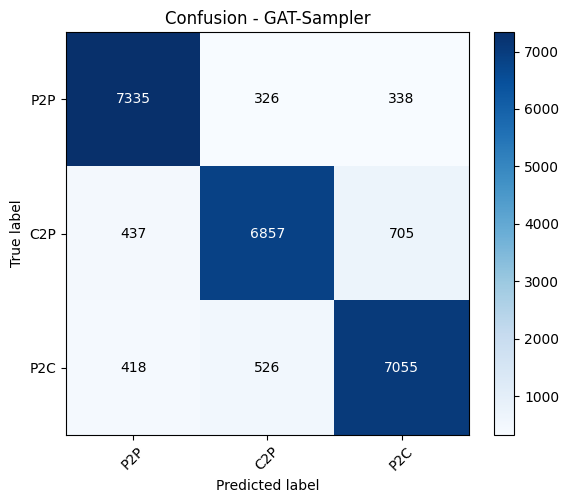

Normalized confusion matrix (%)


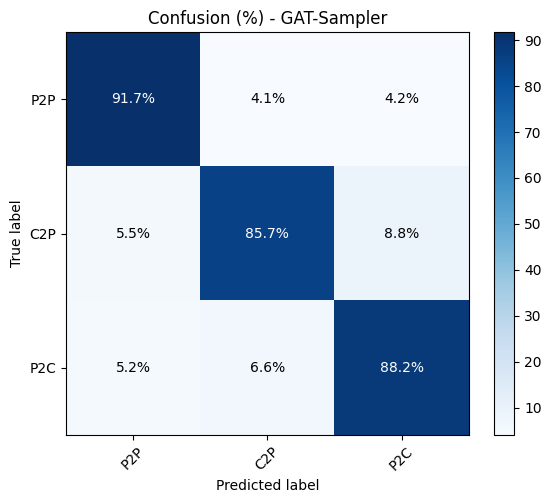

              precision    recall  f1-score   support

         P2P     0.8956    0.9170    0.9062      7999
         C2P     0.8895    0.8572    0.8731      7999
         P2C     0.8712    0.8820    0.8766      7999

    accuracy                         0.8854     23997
   macro avg     0.8854    0.8854    0.8853     23997
weighted avg     0.8854    0.8854    0.8853     23997



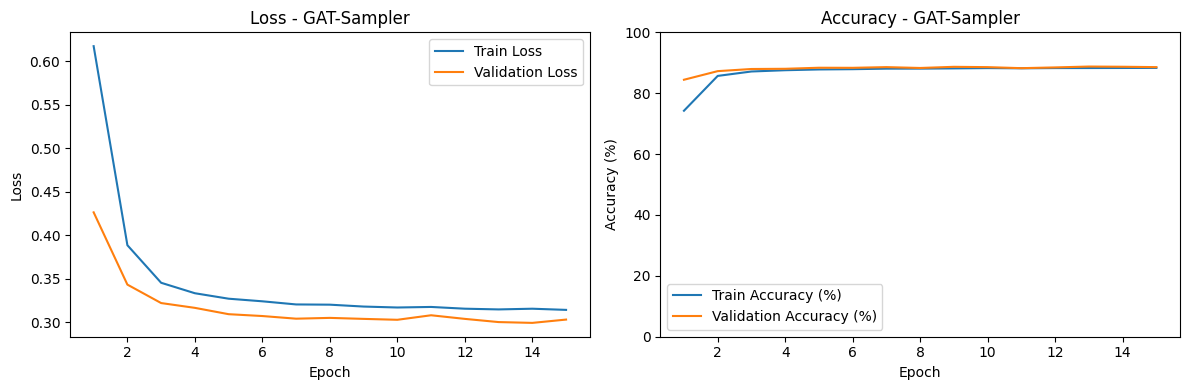

In [ ]:
from tqdm.auto import tqdm
import torch, torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

in_feats  = gnn.dgl_graph.ndata['feat'].shape[1]
n_classes = 3

# Degree features para forzar la asimetría C2P vs P2C en el decoder
g = gnn.dgl_graph
g.ndata["log_out_deg"] = torch.log1p(g.out_degrees().float())
g.ndata["log_in_deg"]  = torch.log1p(g.in_degrees().float())

for name, Model in models.items():
    print(f"\n===== Training {name} =====")

    model = Model(in_feats, 
                  GLOBAL_CONFIG['hidden_dim'], 
                  GLOBAL_CONFIG['out_dim'], out_feats_mlp=n_classes).to(device)
    optim     = torch.optim.Adam(model.parameters(), lr=GLOBAL_CONFIG['lr'], weight_decay=GLOBAL_CONFIG['weight_decay'])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optim, 'min', patience=8, factor=0.5)

    hist = {"loss_tr": [], "acc_tr": [], "loss_val": [], "acc_val": []}
    best_loss, best_state, wait = 1e9, None, 0

    t0 = time.perf_counter()
    for epoch in range(1, 15 + 1):

        # ── TRAIN ──────────────────────────────────────────────────────
        model.train()
        loss_sum = corr = tot = 0

        for _, pair_graph, blocks in tqdm(train_loader, desc=f"Epoch {epoch:03d}", leave=False):
            x      = blocks[0].srcdata['feat']         # input node features
            labels = pair_graph.edata['label'].long()  # batch edge labels

            h      = model.encode(blocks, x)           # embeddings via neighbor sampling
            logits = model.decodeMLP(pair_graph, h)    # edge logits (batch_size, 3)
            loss   = focal_loss(logits, labels, gamma=GLOBAL_CONFIG['focal_gamma'])

            optim.zero_grad()
            loss.backward()
            optim.step()

            loss_sum += loss.item() * len(labels)
            corr     += (logits.argmax(1) == labels).sum().item()
            tot      += len(labels)

        loss_tr = loss_sum / tot if tot > 0 else 0.0
        acc_tr  = 100 * corr / tot if tot > 0 else 0.0

        # ── VALIDATION ─────────────────────────────────────────────────
        model.eval()
        loss_sum = corr = tot = 0

        with torch.no_grad():
            for _, pair_graph, blocks in val_loader:
                x      = blocks[0].srcdata['feat']
                labels = pair_graph.edata['label'].long()

                h      = model.encode(blocks, x)
                logits = model.decodeMLP(pair_graph, h)

                loss_sum += F.cross_entropy(logits, labels).item() * len(labels)
                corr     += (logits.argmax(1) == labels).sum().item()
                tot      += len(labels)

        loss_val = loss_sum / tot if tot > 0 else 0.0
        acc_val  = 100 * corr / tot if tot > 0 else 0.0

        scheduler.step(loss_val)

        hist['loss_tr'].append(loss_tr);   hist['acc_tr'].append(acc_tr)
        hist['loss_val'].append(loss_val); hist['acc_val'].append(acc_val)

        # Early stopping based on validation loss
        if loss_val < best_loss - 1e-4:
            best_loss, wait = loss_val, 0
            best_state = {k: v.cpu() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= GLOBAL_CONFIG['patience']:
                print(f"Early stopping at epoch {epoch}")
                break

        if epoch % 5 == 0 or epoch == 1:
            print(f"ep{epoch:03d} | loss_tr {loss_tr:.4f}  acc_tr {acc_tr:.2f}% | "
                  f"loss_val {loss_val:.4f}  acc_val {acc_val:.2f}%")

    # ── FINAL EVALUATION (test) ────────────────────────────────────────
    tiempo_total = time.perf_counter() - t0
    mins, secs = divmod(tiempo_total, 60)
    print(f"\n{'='*50}")
    print(f"[TIEMPO] {name} (NeighborSampling): {int(mins)}m {secs:.1f}s  ({tiempo_total:.1f}s total)")
    print(f"{'='*50}")

    model.load_state_dict(best_state)
    model.eval()
    preds_all, truth_all = [], []

    with torch.no_grad():
        for _, pair_graph, blocks in test_loader:
            x      = blocks[0].srcdata['feat']
            labels = pair_graph.edata['label'].long()

            h      = model.encode(blocks, x)
            logits = model.decodeMLP(pair_graph, h)

            preds_all.append(logits.argmax(1).cpu())
            truth_all.append(labels.cpu())

    preds = torch.cat(preds_all)
    truth = torch.cat(truth_all)

    cm = confusion_matrix(truth, preds)
    plot_confusion_matrix_2(cm, ["P2P","C2P","P2C"], normalize=False, title=f"Confusion - {name}")
    plot_confusion_matrix_2(cm, ["P2P","C2P","P2C"], normalize=True,  title=f"Confusion (%) - {name}")
    print(classification_report(truth, preds, digits=4, target_names=["P2P","C2P","P2C"]))

    # ── Training curves ────────────────────────────────────────────────
    ep_axis = range(1, len(hist['loss_tr']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(ep_axis, hist['loss_tr'],  label='Train Loss')
    axes[0].plot(ep_axis, hist['loss_val'], label='Validation Loss')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].set_title(f'Loss - {name}'); axes[0].legend()

    axes[1].plot(ep_axis, hist['acc_tr'],  label='Train Accuracy (%)')
    axes[1].plot(ep_axis, hist['acc_val'], label='Validation Accuracy (%)')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)'); axes[1].set_ylim(0, 100)
    axes[1].set_title(f'Accuracy - {name}'); axes[1].legend()

    plt.tight_layout(); plt.show()


## Caso 3: Se utiliza grafo con atributos de PeeringDB y muestreo basado en comunidades (ClusterGCN)

In [ ]:

from modules.gnn_models import (
    GCN2L,
    GraphSAGE2L,
    GAT2L,
    GCN3L,
    GraphSAGE3L,
    GAT3L,
    GCNSampler2L,
    GraphSAGESample2L,
    GATSample2L
)

models = {
    "GCN-Sampler":  GCNSampler2L,
    "SAGE-Sampler": GraphSAGESample2L,
    "GAT-Sampler":  GATSample2L
}


In [ ]:
# 1. Load data with the new format (node_id/asn + src_id/dst_id/relationship)
gnn = GNN(debug=True)
gnn.load_dataset(str(nodes_file), str(edges_file))

gnn.split_edges_classification(
    train_size=0.8,
    val_size=0.15,
    seed=42,
    balance_mode="strict_equal",   # use "proportional" to keep natural class distribution
)

g0 = gnn.dgl_graph
print("\n[Loaded graph summary]")
print(f"- Nodes: {g0.num_nodes():,}")
print(f"- Edges: {g0.num_edges():,}")
print(f"- Feature dimension: {g0.ndata['feat'].shape[1]}")
print(f"- Edge data keys: {list(g0.edata.keys())}")
print(f"- Train edges: {g0.edata['train_mask'].sum().item():,}")
print(f"- Validation edges: {g0.edata['val_mask'].sum().item():,}")
print(f"- Test edges: {g0.edata['test_mask'].sum().item():,}")
if "label" in g0.edata:
    print(f"- Global label distribution: {Counter(g0.edata['label'].tolist())}")
    tr = g0.edata['label'][g0.edata['train_mask']]
    va = g0.edata['label'][g0.edata['val_mask']]
    te = g0.edata['label'][g0.edata['test_mask']]
    print(f"- Train distribution: {Counter(tr.tolist())}")
    print(f"- Validation distribution: {Counter(va.tolist())}")
    print(f"- Test distribution: {Counter(te.tolist())}")


Grafo cargado: 79504 nodos, 807496 aristas
Aristas en ambos sentidos: True
Dimensión de entrada (in_feats): 72
Edge features: 1 dim

[SPLIT COMPLETO - ESTRATIFICADO]
Modo balanceo: strict_equal
Etiqueta usada: label
Total aristas etiquetadas: 660438
Train: 383910 | Val: 71982 | Test: 23997
Distribución Train: {1: 127970, 0: 127970, 2: 127970}
Distribución Val:   {0: 23994, 2: 23994, 1: 23994}
Distribución Test:  {2: 7999, 1: 7999, 0: 7999}

[Loaded graph summary]
- Nodes: 79,504
- Edges: 807,496
- Feature dimension: 72
- Edge data keys: ['label', 'edge_feat', 'train_mask', 'val_mask', 'test_mask']
- Train edges: 383,910
- Validation edges: 71,982
- Test edges: 23,997
- Global label distribution: Counter({0: 340512, 1: 159963, 2: 159963, -1: 147058})
- Train distribution: Counter({1: 127970, 2: 127970, 0: 127970})
- Validation distribution: Counter({1: 23994, 0: 23994, 2: 23994})
- Test distribution: Counter({1: 7999, 0: 7999, 2: 7999})


In [ ]:
num_parts = 1000
device    = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 1024

sampler = dgl.dataloading.ClusterGCNSampler(
    gnn.dgl_graph, num_parts,
    prefetch_ndata=['feat'],
    prefetch_edata=['label', 'train_mask', 'val_mask', 'test_mask']
)

cluster_ids = torch.arange(num_parts)

train_loader = dgl.dataloading.DataLoader(
    gnn.dgl_graph, 
    cluster_ids, sampler,
    batch_size=BATCH_SIZE, 
    shuffle=True,  
    drop_last=False, 
    device=device)

val_loader = dgl.dataloading.DataLoader(
    gnn.dgl_graph, 
    cluster_ids, 
    sampler,
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    drop_last=False, 
    device=device)

test_loader = dgl.dataloading.DataLoader(
    gnn.dgl_graph, 
    cluster_ids, 
    sampler,
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    drop_last=False, 
    device=device)

print(f"Device:      {device}")
print(f"Clusters:    {num_parts}  |  Batch size: {BATCH_SIZE}")
print(f"Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}  |  Test batches: {len(test_loader)}")


Convert a graph into a bidirected graph: 0.023 seconds, peak memory: 7.201 GB
Construct multi-constraint weights: 0.000 seconds, peak memory: 7.201 GB
Metis partitioning: 0.761 seconds, peak memory: 7.201 GB
Device:      cpu
Clusters:    1000  |  Batch size: 32
Train batches: 32  |  Val batches: 32  |  Test batches: 32


[03:55:03] /opt/dgl/src/graph/transform/metis_partition_hetero.cc:89: Partition a graph with 79504 nodes and 807496 edges into 1000 parts and get 328476 edge cuts



===== Training GCN-Sampler =====


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/dgl/dataloading/dataloader.py:1149: DGLWarning: Dataloader CPU affinity opt is not enabled, consider switching it on (see enable_cpu_affinity() or CPU best practices for DGL [https://docs.dgl.ai/tutorials/cpu/cpu_best_practises.html])
  dgl_warning(


Epoch 001:   0%|          | 0/32 [00:00<?, ?it/s]

ep001 | loss_tr 0.7916  acc_tr 76.41% | loss_val 0.9956  acc_val 80.66%


Epoch 002:   0%|          | 0/32 [00:00<?, ?it/s]

...

Epoch 012:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 013:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 014:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 015:   0%|          | 0/32 [00:00<?, ?it/s]

ep015 | loss_tr 0.2319  acc_tr 91.58% | loss_val 0.2706  acc_val 90.27%

[TIEMPO] GCN-Sampler (ClusterGCN): 0m 15.6s  (15.6s total)
Confusion matrix (not normalized)


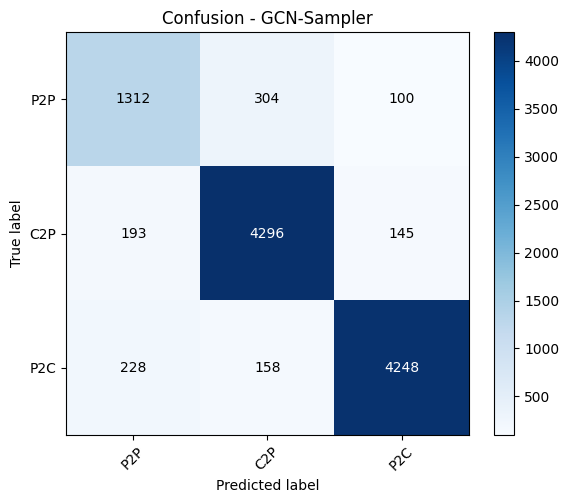

Normalized confusion matrix (%)


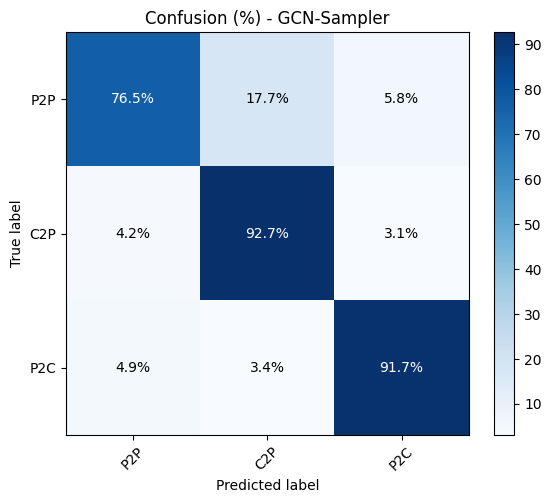

              precision    recall  f1-score   support

         P2P     0.7571    0.7646    0.7608      1716
         C2P     0.9029    0.9271    0.9148      4634
         P2C     0.9455    0.9167    0.9309      4634

    accuracy                         0.8973     10984
   macro avg     0.8685    0.8694    0.8688     10984
weighted avg     0.8981    0.8973    0.8975     10984



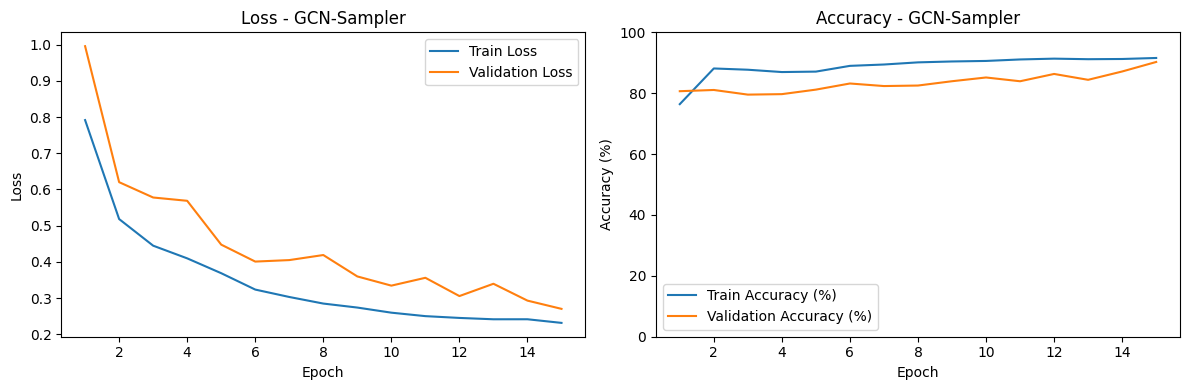


===== Training SAGE-Sampler =====


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/dgl/dataloading/dataloader.py:1149: DGLWarning: Dataloader CPU affinity opt is not enabled, consider switching it on (see enable_cpu_affinity() or CPU best practices for DGL [https://docs.dgl.ai/tutorials/cpu/cpu_best_practises.html])
  dgl_warning(


Epoch 001:   0%|          | 0/32 [00:00<?, ?it/s]

ep001 | loss_tr 0.8349  acc_tr 64.02% | loss_val 0.8027  acc_val 72.35%


Epoch 002:   0%|          | 0/32 [00:00<?, ?it/s]

...

Epoch 012:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 013:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 014:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 015:   0%|          | 0/32 [00:00<?, ?it/s]

ep015 | loss_tr 0.3280  acc_tr 87.66% | loss_val 0.3097  acc_val 89.81%

[TIEMPO] SAGE-Sampler (ClusterGCN): 0m 16.0s  (16.0s total)
Confusion matrix (not normalized)


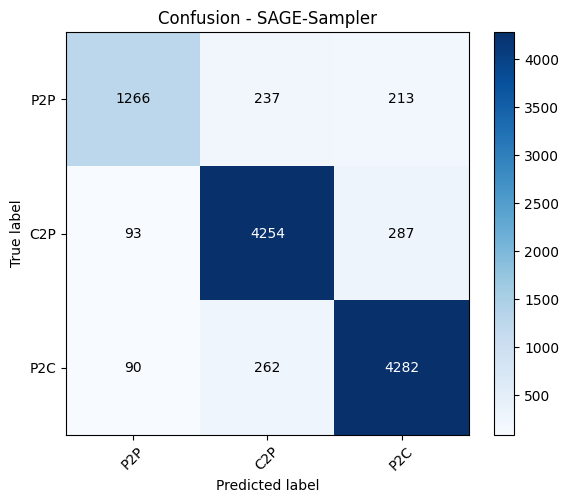

Normalized confusion matrix (%)


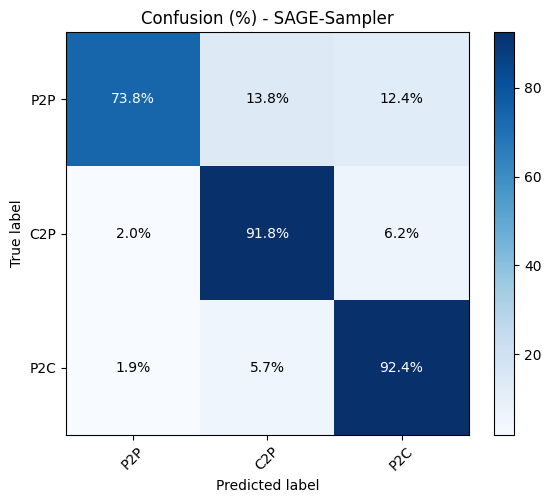

              precision    recall  f1-score   support

         P2P     0.8737    0.7378    0.8000      1716
         C2P     0.8950    0.9180    0.9064      4634
         P2C     0.8954    0.9240    0.9095      4634

    accuracy                         0.8924     10984
   macro avg     0.8881    0.8599    0.8720     10984
weighted avg     0.8919    0.8924    0.8911     10984



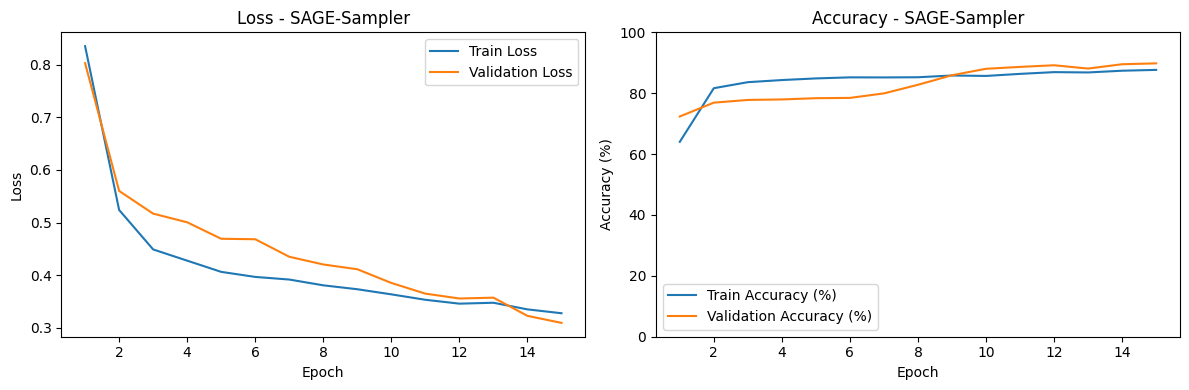


===== Training GAT-Sampler =====


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/dgl/dataloading/dataloader.py:1149: DGLWarning: Dataloader CPU affinity opt is not enabled, consider switching it on (see enable_cpu_affinity() or CPU best practices for DGL [https://docs.dgl.ai/tutorials/cpu/cpu_best_practises.html])
  dgl_warning(


Epoch 001:   0%|          | 0/32 [00:00<?, ?it/s]

ep001 | loss_tr 0.8378  acc_tr 65.13% | loss_val 0.7292  acc_val 75.46%


Epoch 002:   0%|          | 0/32 [00:00<?, ?it/s]

...

Epoch 012:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 013:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 014:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 015:   0%|          | 0/32 [00:00<?, ?it/s]

ep015 | loss_tr 0.3455  acc_tr 86.13% | loss_val 0.3439  acc_val 86.68%

[TIEMPO] GAT-Sampler (ClusterGCN): 0m 18.9s  (18.9s total)
Confusion matrix (not normalized)


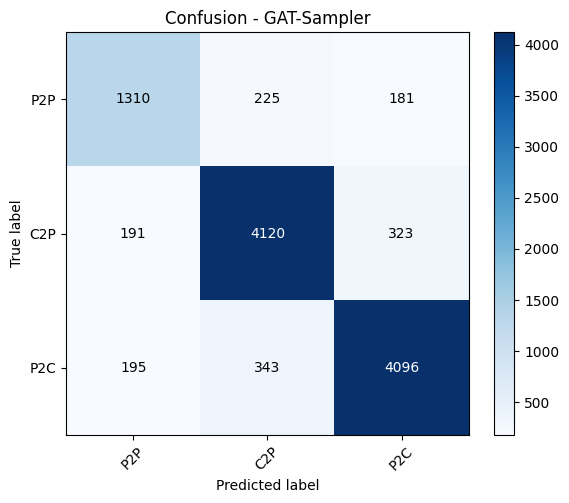

Normalized confusion matrix (%)


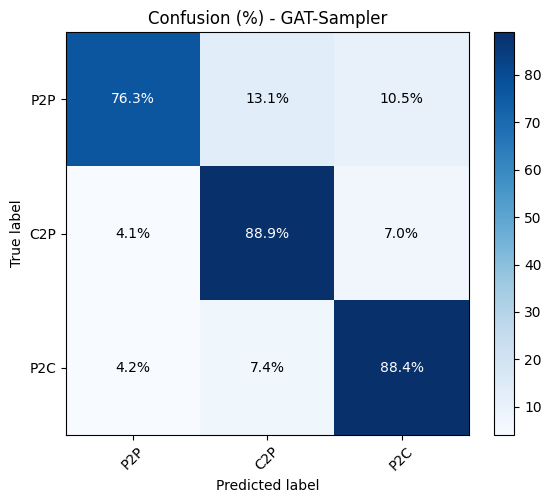

              precision    recall  f1-score   support

         P2P     0.7724    0.7634    0.7679      1716
         C2P     0.8788    0.8891    0.8839      4634
         P2C     0.8904    0.8839    0.8872      4634

    accuracy                         0.8673     10984
   macro avg     0.8472    0.8455    0.8463     10984
weighted avg     0.8671    0.8673    0.8672     10984



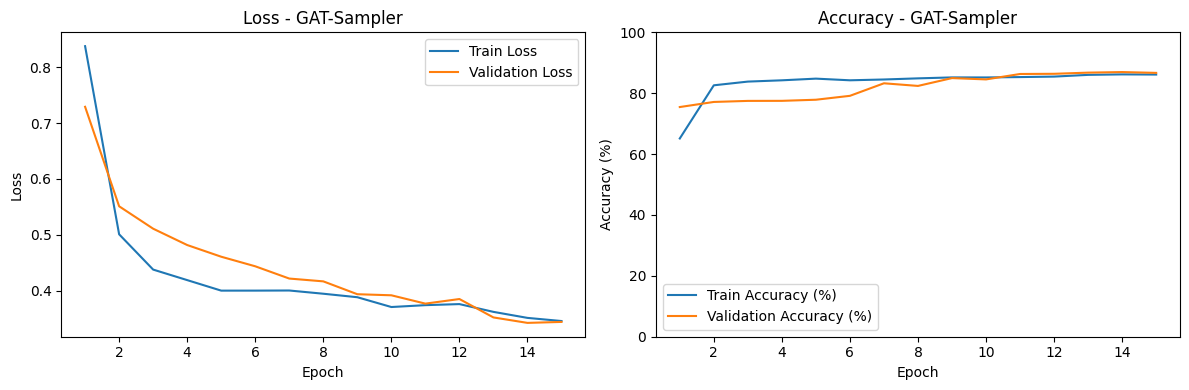

In [ ]:
from tqdm.auto import tqdm
import torch, torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

in_feats  = gnn.dgl_graph.ndata['feat'].shape[1]
n_classes = 3

# Degree features para forzar la asimetría C2P vs P2C en el decoder
g = gnn.dgl_graph
g.ndata["log_out_deg"] = torch.log1p(g.out_degrees().float())
g.ndata["log_in_deg"]  = torch.log1p(g.in_degrees().float())

for name, Model in models.items():
    print(f"\n===== Training {name} =====")

    model = Model(in_feats, 
                  GLOBAL_CONFIG['hidden_dim'], 
                  GLOBAL_CONFIG['out_dim'], 
                  out_feats_mlp=n_classes).to(device)
    
    optim    = torch.optim.Adam(model.parameters(), lr=GLOBAL_CONFIG['lr'], weight_decay=GLOBAL_CONFIG['weight_decay'])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optim, 'min', patience=8, factor=0.5)

    hist = {"loss_tr": [], "acc_tr": [], "loss_val": [], "acc_val": []}
    best_loss, best_state, wait = 1e9, None, 0

    t0 = time.perf_counter()
    for epoch in range(1, 15 + 1):

        # ── TRAIN ──────────────────────────────────────────────────────────
        model.train()
        loss_sum = corr = tot = 0

        for subg in tqdm(train_loader, desc=f"Epoch {epoch:03d}", leave=False):
            if subg.num_edges() == 0:
                continue
            x = subg.ndata['feat'].float()
            y = subg.edata['label'].long()
            m = subg.edata['train_mask'].bool()
            if m.sum() == 0:
                continue

            h      = model.encode(subg, x)
            logits = model.decodeMLP(subg, h)
            loss   = focal_loss(logits[m], y[m], gamma=GLOBAL_CONFIG['focal_gamma'])

            optim.zero_grad()
            loss.backward()
            optim.step()

            loss_sum += loss.item() * m.sum().item()
            corr     += (logits[m].argmax(1) == y[m]).sum().item()
            tot      += m.sum().item()

        loss_tr = loss_sum / tot if tot > 0 else 0.0
        acc_tr  = 100 * corr / tot if tot > 0 else 0.0

        # ── VALIDATION ─────────────────────────────────────────────────────
        model.eval()
        loss_sum = corr = tot = 0

        with torch.no_grad():
            for subg in val_loader:
                if subg.num_edges() == 0:
                    continue
                x = subg.ndata['feat'].float()
                y = subg.edata['label'].long()
                m = subg.edata['val_mask'].bool()
                if m.sum() == 0:
                    continue

                h      = model.encode(subg, x)
                logits = model.decodeMLP(subg, h)

                loss_sum += F.cross_entropy(logits[m], y[m]).item() * m.sum().item()
                corr     += (logits[m].argmax(1) == y[m]).sum().item()
                tot      += m.sum().item()

        loss_val = loss_sum / tot if tot > 0 else 0.0
        acc_val  = 100 * corr / tot if tot > 0 else 0.0

        scheduler.step(loss_val)

        hist['loss_tr'].append(loss_tr);   hist['acc_tr'].append(acc_tr)
        hist['loss_val'].append(loss_val); hist['acc_val'].append(acc_val)

        # Early stopping based on validation loss
        if loss_val < best_loss - 1e-4:
            best_loss, wait = loss_val, 0
            best_state = {k: v.cpu() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= GLOBAL_CONFIG['patience']:
                print(f"Early stopping at epoch {epoch}")
                break

        if epoch % 5 == 0 or epoch == 1:
            print(f"ep{epoch:03d} | loss_tr {loss_tr:.4f}  acc_tr {acc_tr:.2f}% | "
                  f"loss_val {loss_val:.4f}  acc_val {acc_val:.2f}%")

    # ── FINAL EVALUATION (test) ────────────────────────────────────────────
    tiempo_total = time.perf_counter() - t0
    mins, secs = divmod(tiempo_total, 60)
    print(f"\n{'='*50}")
    print(f"[TIEMPO] {name} (ClusterGCN): {int(mins)}m {secs:.1f}s  ({tiempo_total:.1f}s total)")
    print(f"{'='*50}")

    model.load_state_dict(best_state)
    model.eval()
    preds_all, truth_all = [], []

    with torch.no_grad():
        for subg in test_loader:
            if subg.num_edges() == 0:
                continue
            x = subg.ndata['feat'].float()
            y = subg.edata['label'].long()
            m = subg.edata['test_mask'].bool()
            if m.sum() == 0:
                continue

            h      = model.encode(subg, x)
            logits = model.decodeMLP(subg, h)

            preds_all.append(logits[m].argmax(1).cpu())
            truth_all.append(y[m].cpu())

    preds = torch.cat(preds_all)
    truth = torch.cat(truth_all)

    cm = confusion_matrix(truth, preds)
    plot_confusion_matrix_2(cm, ["P2P","C2P","P2C"], normalize=False, title=f"Confusion - {name}")
    plot_confusion_matrix_2(cm, ["P2P","C2P","P2C"], normalize=True,  title=f"Confusion (%) - {name}")
    print(classification_report(truth, preds, digits=4, target_names=["P2P","C2P","P2C"]))

    # ── Training curves ────────────────────────────────────────────────────
    ep_axis = range(1, len(hist['loss_tr']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(ep_axis, hist['loss_tr'],  label='Train Loss')
    axes[0].plot(ep_axis, hist['loss_val'], label='Validation Loss')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].set_title(f'Loss - {name}'); axes[0].legend()

    axes[1].plot(ep_axis, hist['acc_tr'],  label='Train Accuracy (%)')
    axes[1].plot(ep_axis, hist['acc_val'], label='Validation Accuracy (%)')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)'); axes[1].set_ylim(0, 100)
    axes[1].set_title(f'Accuracy - {name}'); axes[1].legend()

    plt.tight_layout(); plt.show()


## Caso 4: Se utiliza grafo con atributos de nodos generados aleatoriamente

In [ ]:
models = {
    'GCN': GCN3L,
    'GraphSAGE': GraphSAGE3L,
    'GAT': GAT3L,
}



# 1. Load data with the new format (node_id/asn + src_id/dst_id/relationship)
gnn = GNN(debug=True)
gnn.load_dataset(str(nodes_file), str(edges_file))


gnn.add_random_features(dim=64, std=0.05, seed=42, mode="uniform")


gnn.split_edges_classification(
    train_size=0.8,
    val_size=0.15,
    seed=42,
    balance_mode="strict_equal",   # use "proportional" to keep natural class distribution
)

g0 = gnn.dgl_graph

Grafo cargado: 79504 nodos, 807496 aristas
Aristas en ambos sentidos: True
Dimensión de entrada (in_feats): 72
Edge features: 1 dim
[add_random_features] feat ← (79504, 64)  |  mode=uniform

[SPLIT COMPLETO - ESTRATIFICADO]
Modo balanceo: strict_equal
Etiqueta usada: label
Total aristas etiquetadas: 660438
Train: 383910 | Val: 71982 | Test: 23997
Distribución Train: {1: 127970, 0: 127970, 2: 127970}
Distribución Val:   {0: 23994, 2: 23994, 1: 23994}
Distribución Test:  {2: 7999, 1: 7999, 0: 7999}



 Training GCN 
 ---------------
ep01 | loss_tr 1.0973 acc_tr 39.34% | loss_te 0.9537 acc_te 55.97%
ep10 | loss_tr 0.8230 acc_tr 54.90% | loss_te 0.7915 acc_te 55.00%
ep20 | loss_tr 0.7715 acc_tr 67.64% | loss_te 0.7572 acc_te 67.92%
ep30 | loss_tr 0.6937 acc_tr 76.45% | loss_te 0.7795 acc_te 62.62%
ep40 | loss_tr 0.5841 acc_tr 85.12% | loss_te 0.8683 acc_te 61.01%
ep50 | loss_tr 0.5548 acc_tr 80.29% | loss_te 0.6692 acc_te 75.94%
ep60 | loss_tr 0.4649 acc_tr 87.24% | loss_te 0.9257 acc_te 68.06%
ep70 | loss_tr 0.4563 acc_tr 87.49% | loss_te 0.8548 acc_te 72.61%
ep80 | loss_tr 0.4039 acc_tr 88.21% | loss_te 0.6298 acc_te 76.78%
ep90 | loss_tr 0.4020 acc_tr 87.47% | loss_te 0.7413 acc_te 75.51%
ep100 | loss_tr 0.3917 acc_tr 88.52% | loss_te 1.0166 acc_te 69.13%
ep110 | loss_tr 0.3847 acc_tr 88.13% | loss_te 0.8990 acc_te 72.41%
ep120 | loss_tr 0.4567 acc_tr 84.97% | loss_te 0.8177 acc_te 72.90%
ep130 | loss_tr 0.3775 acc_tr 88.91% | loss_te 0.5465 acc_te 77.76%
ep140 | loss_tr 0.4727 ac

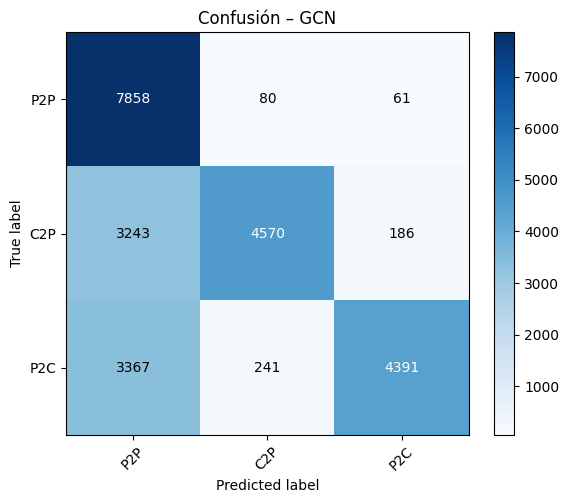

Normalized confusion matrix (%)


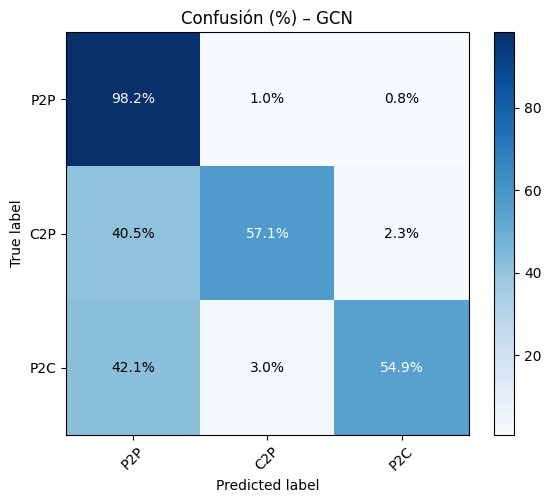

              precision    recall  f1-score   support

           0     0.5431    0.9824    0.6995      7999
           1     0.9344    0.5713    0.7091      7999
           2     0.9467    0.5489    0.6949      7999

    accuracy                         0.7009     23997
   macro avg     0.8081    0.7009    0.7012     23997
weighted avg     0.8081    0.7009    0.7012     23997



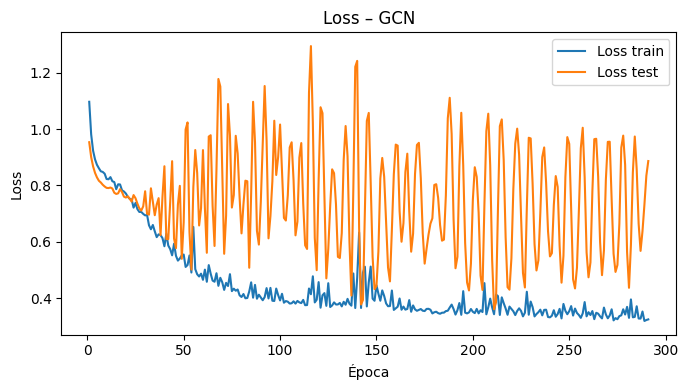

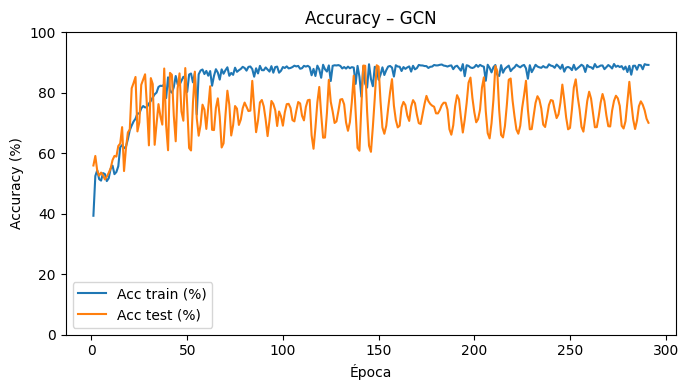


 Training GraphSAGE 
 ---------------
ep01 | loss_tr 1.3379 acc_tr 33.44% | loss_te 1.1102 acc_te 34.00%
ep10 | loss_tr 1.0898 acc_tr 38.22% | loss_te 1.0900 acc_te 41.88%
ep20 | loss_tr 1.0693 acc_tr 42.69% | loss_te 1.0838 acc_te 34.54%
ep30 | loss_tr 1.0240 acc_tr 48.60% | loss_te 1.0331 acc_te 46.23%
ep40 | loss_tr 0.9709 acc_tr 52.14% | loss_te 0.9617 acc_te 52.74%
ep50 | loss_tr 0.8651 acc_tr 60.19% | loss_te 0.8512 acc_te 61.63%
ep60 | loss_tr 0.7573 acc_tr 67.85% | loss_te 0.7643 acc_te 65.29%
ep70 | loss_tr 0.6689 acc_tr 72.00% | loss_te 0.6938 acc_te 68.32%
ep80 | loss_tr 0.6005 acc_tr 76.38% | loss_te 0.6156 acc_te 73.06%
ep90 | loss_tr 0.5678 acc_tr 77.82% | loss_te 0.7037 acc_te 66.52%
ep100 | loss_tr 0.5269 acc_tr 79.88% | loss_te 0.5631 acc_te 75.64%
ep110 | loss_tr 0.5308 acc_tr 78.69% | loss_te 0.6717 acc_te 68.94%
ep120 | loss_tr 0.4930 acc_tr 81.07% | loss_te 0.7798 acc_te 63.99%
ep130 | loss_tr 0.4846 acc_tr 81.63% | loss_te 0.7227 acc_te 66.83%
ep140 | loss_tr 0.4

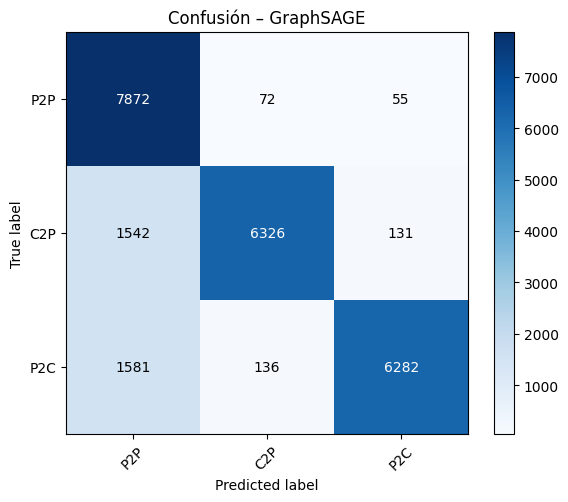

Normalized confusion matrix (%)


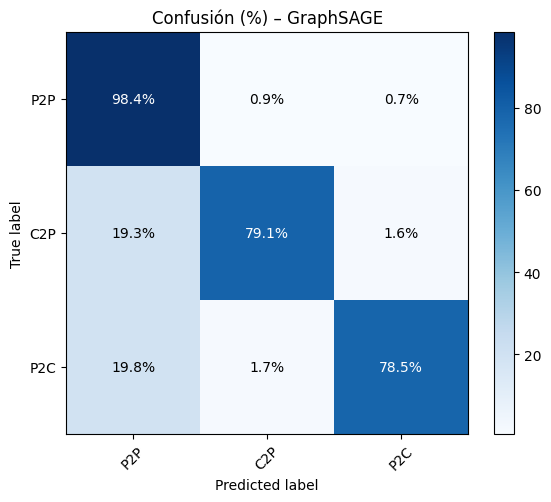

              precision    recall  f1-score   support

           0     0.7160    0.9841    0.8289      7999
           1     0.9682    0.7908    0.8706      7999
           2     0.9712    0.7853    0.8685      7999

    accuracy                         0.8534     23997
   macro avg     0.8851    0.8534    0.8560     23997
weighted avg     0.8851    0.8534    0.8560     23997



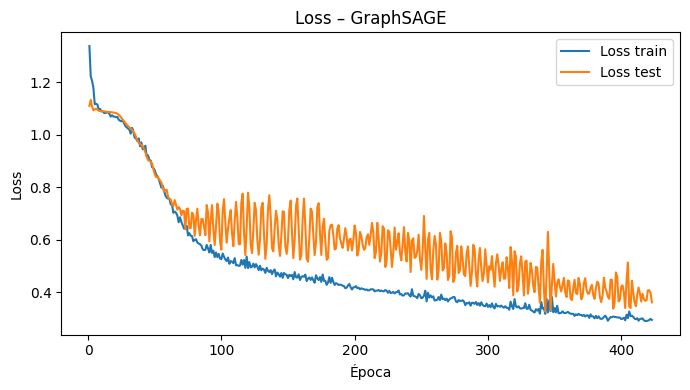

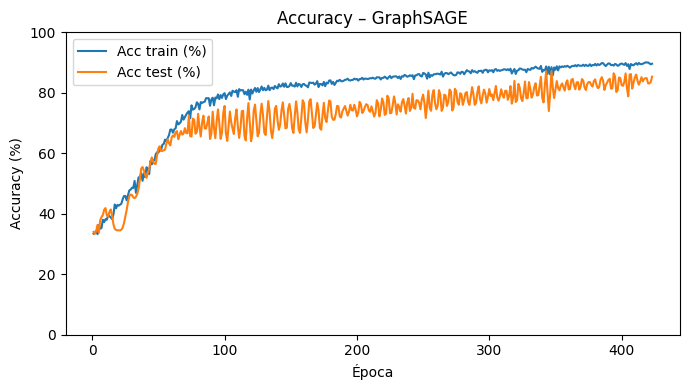


 Training GAT 
 ---------------
ep01 | loss_tr 1.1224 acc_tr 33.13% | loss_te 1.0996 acc_te 33.35%
ep10 | loss_tr 1.0853 acc_tr 42.15% | loss_te 1.0935 acc_te 37.05%
ep20 | loss_tr 1.0636 acc_tr 52.35% | loss_te 1.0820 acc_te 43.57%
ep30 | loss_tr 1.0200 acc_tr 56.38% | loss_te 1.0539 acc_te 55.56%
ep40 | loss_tr 0.9101 acc_tr 60.82% | loss_te 0.9934 acc_te 50.80%
ep50 | loss_tr 0.8471 acc_tr 64.41% | loss_te 1.0548 acc_te 33.84%
ep60 | loss_tr 0.7923 acc_tr 69.32% | loss_te 0.9900 acc_te 34.01%
ep70 | loss_tr 0.6747 acc_tr 73.62% | loss_te 1.8482 acc_te 38.26%
ep80 | loss_tr 0.6378 acc_tr 74.51% | loss_te 1.6358 acc_te 48.74%
ep90 | loss_tr 0.5396 acc_tr 77.61% | loss_te 1.4839 acc_te 48.81%
ep100 | loss_tr 0.5438 acc_tr 78.48% | loss_te 1.6417 acc_te 48.65%
ep110 | loss_tr 0.5001 acc_tr 79.85% | loss_te 1.4383 acc_te 48.47%
ep120 | loss_tr 0.5417 acc_tr 79.33% | loss_te 1.4704 acc_te 48.93%
ep130 | loss_tr 0.5085 acc_tr 80.04% | loss_te 1.3149 acc_te 50.40%
ep140 | loss_tr 0.4844 ac

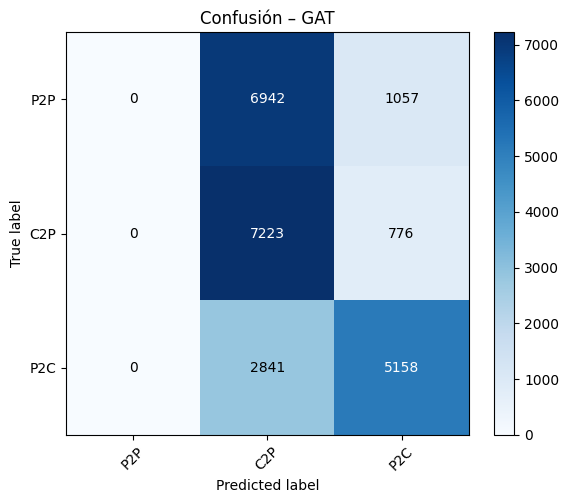

Normalized confusion matrix (%)


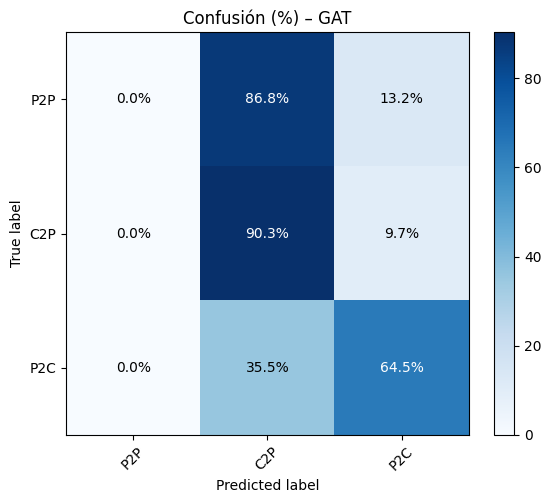

              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      7999
           1     0.4247    0.9030    0.5777      7999
           2     0.7378    0.6448    0.6882      7999

    accuracy                         0.5159     23997
   macro avg     0.3875    0.5159    0.4220     23997
weighted avg     0.3875    0.5159    0.4220     23997



/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

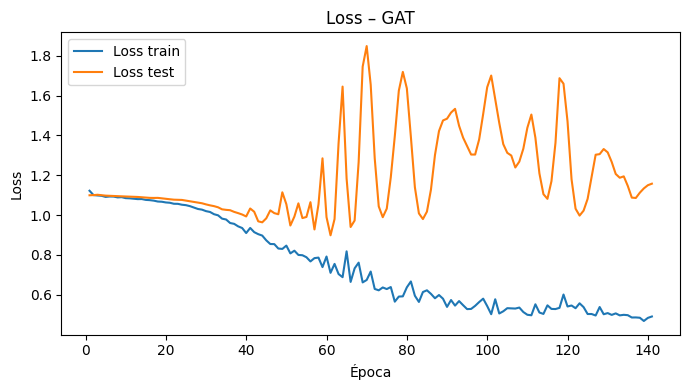

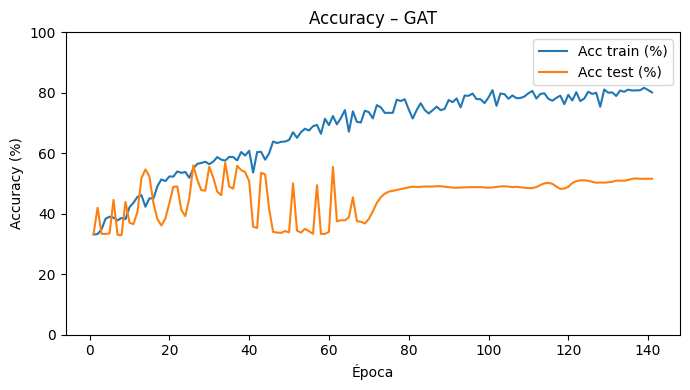

In [ ]:
import torch, torch.nn.functional as F
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Parámetros 
# ------------------------------------------
in_feats  = gnn.dgl_graph.ndata["feat"].shape[1]
device    = "cuda" if torch.cuda.is_available() else "cpu"
lr        = GLOBAL_CONFIG['lr']
patience  = GLOBAL_CONFIG['patience']
n_classes = 3

# Datos y máscaras 
# ------------------------------------------
g       = gnn.dgl_graph.to(device)
feat    = g.ndata["feat"].to(device)
label_key = next((k for k in ["label", "relationship", "Relationship"] if k in g.edata), None)
labels  = g.edata[label_key].long().to(device)
train_m = g.edata["train_mask"].to(device)
test_m  = g.edata["test_mask"].to(device)

for name, Model in models.items():
    print(f"\n Training {name} \n ---------------")

    model = Model(in_feats, GLOBAL_CONFIG['hidden_dim'], GLOBAL_CONFIG['out_dim'], out_feats_mlp=n_classes).to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=GLOBAL_CONFIG['weight_decay'])

    # histórico por modelo
    hist = {"loss_tr": [], "acc_tr": [], "loss_te": [], "acc_te": []}
    best_loss, wait = 1e9, 0

    t0 = time.perf_counter()
    for ep in range(1, GLOBAL_CONFIG['epochs'] + 1):
        # Entrenamiento 
        # ----------
        model.train()
        h      = model.encode(g, feat)
        logits = model.decodeMLP(g, h)                  # (E, 3)

        loss   = F.cross_entropy(logits[train_m], labels[train_m])
        # loss   = F.cross_entropy(logits[train_m], labels[train_m], weight=class_weights)

        
        opt.zero_grad() 
        loss.backward()
        opt.step()

        with torch.no_grad():
            preds_tr = logits[train_m].argmax(1)
            acc_tr   = (preds_tr == labels[train_m]).float().mean().item()

        # ---------- test ----------
        model.eval()
        with torch.no_grad():
            logits_t = model.decodeMLP(g, model.encode(g, feat))
            loss_te  = F.cross_entropy(logits_t[test_m], labels[test_m])
            # loss_te  = F.cross_entropy(logits_t[test_m], labels[test_m], weight=class_weights)
            preds_t  = logits_t[test_m].argmax(1)
            acc_t    = (preds_t == labels[test_m]).float().mean().item()

        # guarda histórico
        hist["loss_tr"].append(loss.item())
        hist["acc_tr"].append(acc_tr * 100)
        hist["loss_te"].append(loss_te.item())
        hist["acc_te"].append(acc_t * 100)

        # early-stopping
        if loss_te < best_loss - 1e-4:
            best_loss, wait = loss_te, 0
            best_w = model.state_dict()
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stop en época {ep}")
                break

        if ep % 10 == 0 or ep == 1:
            print(f"ep{ep:02d} | loss_tr {loss:.4f} acc_tr {acc_tr:.2%} | "
                  f"loss_te {loss_te:.4f} acc_te {acc_t:.2%}")

    tiempo_total = time.perf_counter() - t0
    mins, secs = divmod(tiempo_total, 60)
    print(f"\n{'='*50}")
    print(f"[TIEMPO] {name}: {int(mins)}m {secs:.1f}s  ({tiempo_total:.1f}s total)")
    print(f"{'='*50}")

    # ---------- evaluación final ----------
    model.load_state_dict(best_w)
    with torch.no_grad():
        logits_best = model.decodeMLP(g, model.encode(g, feat))
        preds_best  = logits_best[test_m].argmax(1).cpu()
        truth       = labels[test_m].cpu()

    cm = confusion_matrix(truth, preds_best)
    plot_confusion_matrix_2(cm, ["P2P","C2P","P2C"], False,
                            title=f"Confusión – {name}")
    plot_confusion_matrix_2(cm, ["P2P","C2P","P2C"], True,
                            title=f"Confusión (%) – {name}")

    print(classification_report(truth, preds_best, digits=4))

    # ---------- curvas de entrenamiento ----------
    epochs_done = range(1, len(hist["loss_tr"]) + 1)

    plt.figure(figsize=(7,4))
    plt.plot(epochs_done, hist["loss_tr"], label="Loss train")
    plt.plot(epochs_done, hist["loss_te"], label="Loss test")
    plt.xlabel("Época"); plt.ylabel("Loss"); plt.title(f"Loss – {name}")
    plt.legend(); plt.tight_layout(); plt.show()

    plt.figure(figsize=(7,4))
    plt.plot(epochs_done, hist["acc_tr"], label="Acc train (%)")
    plt.plot(epochs_done, hist["acc_te"], label="Acc test (%)")
    plt.xlabel("Época"); plt.ylabel("Accuracy (%)"); plt.ylim(0,100)
    plt.title(f"Accuracy – {name}")
    plt.legend(); plt.tight_layout(); plt.show()


## PREGUNTAS:
* ¿Por que incluso con atributos aleatorios se obtiene una buena accuracy con la GCN?
* ¿Por qué usando random Neighbputhood se obtienen la mejor accuracy?¿Por qué ocurre eso?¿Qué nos dice?
* Al ocupar los attr creados aleatoriamente , opdemos ver q se van aprendindo de memoria y por lo msimo la acurracy ntre mas epochs se emṕieza a separara
* ¿Que informacion del grafo y las GNNS puedo sacar con estos rsulatdos?
* construir hatmap d correlacion entre atributos de perngdb y uno tmb para las centralidades

## Comparación: Todos los modelos
**2L vs 3L × GCN / GraphSAGE / GAT × Decoder MLP / Bilinear**

Entrena las 12 combinaciones con la misma configuración y genera una tabla comparativa.

In [ ]:
import torch, torch.nn.functional as F, pandas as pd
from sklearn.metrics import accuracy_score, f1_score, recall_score

ALL_MODELS = {
    'GCN-2L':    GCN2L,
    'GCN-3L':    GCN3L,
    'SAGE-2L':   GraphSAGE2L,
    'SAGE-3L':   GraphSAGE3L,
    'GAT-2L':    GAT2L,
    'GAT-3L':    GAT3L,
}
ALL_DECODERS = ['MLP', 'Bilinear']

COMP_HIDDEN   = GLOBAL_CONFIG['hidden_dim']
COMP_OUT      = GLOBAL_CONFIG['out_dim']
COMP_LR       = GLOBAL_CONFIG['lr']
COMP_EPOCHS   = GLOBAL_CONFIG['epochs']
COMP_PATIENCE = GLOBAL_CONFIG['patience']


def _train_one(ModelClass, decoder_name, in_feats, n_cls, cw,
               g, feat, labels, train_m, val_m, test_m, device, extra_kw=None):
    if extra_kw is None:
        extra_kw = {}
    model  = ModelClass(in_feats, COMP_HIDDEN, COMP_OUT,
                        out_feats_mlp=n_cls, edge_dim=1,
                        drop=GLOBAL_CONFIG['dropout'], **extra_kw).to(device)
    opt    = torch.optim.Adam(model.parameters(), lr=COMP_LR,
                              weight_decay=GLOBAL_CONFIG['weight_decay'])
    sched  = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(opt, T_0=50, T_mult=2)
    decode = model.decodeBilinear if decoder_name == 'Bilinear' else model.decodeMLP

    best_f1, best_loss, wait, best_w = -1.0, float("inf"), 0, None

    t0 = time.perf_counter()
    for ep in range(1, COMP_EPOCHS + 1):
        model.train()
        logits = decode(g, model.encode(g, feat))
        loss = F.cross_entropy(logits[train_m], labels[train_m],
                               weight=cw, label_smoothing=GLOBAL_CONFIG['label_smooth'])
        opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GLOBAL_CONFIG['grad_clip'])
        opt.step(); sched.step(ep - 1 + 1 / COMP_EPOCHS)

        model.eval()
        with torch.no_grad():
            lv       = decode(g, model.encode(g, feat))
            loss_val = F.cross_entropy(lv[val_m], labels[val_m])
            f1v      = f1_score(labels[val_m].cpu(), lv[val_m].argmax(1).cpu(),
                                average="macro", zero_division=0)

        if f1v > best_f1 + 1e-4 or (abs(f1v - best_f1) <= 1e-4 and loss_val < best_loss - 1e-4):
            best_f1, best_loss, wait, best_w = f1v, loss_val.item(), 0, model.state_dict()
        else:
            wait += 1
            if wait >= COMP_PATIENCE:
                break
    tiempo_total = time.perf_counter() - t0

    model.load_state_dict(best_w or model.state_dict())
    model.eval()
    with torch.no_grad():
        preds = decode(g, model.encode(g, feat))[test_m].argmax(1).cpu()
    truth = labels[test_m].cpu()

    recs = recall_score(truth, preds, labels=[0, 1, 2], average=None, zero_division=0) * 100
    return {
        "Acc%":     round(accuracy_score(truth, preds) * 100, 2),
        "F1-macro": round(f1_score(truth, preds, average="macro",    zero_division=0) * 100, 2),
        "F1-w":     round(f1_score(truth, preds, average="weighted", zero_division=0) * 100, 2),
        "P2P-rec":  round(recs[0], 2),
        "C2P-rec":  round(recs[1], 2),
        "P2C-rec":  round(recs[2], 2),
        "Time (s)": round(tiempo_total, 2),
    }


# ── Setup ────────────────────────────────────────────────────────────────────────
device     = "cuda" if torch.cuda.is_available() else "cpu"
in_feats_c = gnn.dgl_graph.ndata["feat"].shape[1]
g_c        = gnn.dgl_graph.to(device)
feat_c     = g_c.ndata["feat"].to(device)

lk = next((k for k in ["label", "relationship", "Relationship"] if k in g_c.edata), None)
labels_c = g_c.edata[lk].long().to(device)
train_mc = g_c.edata["train_mask"].bool().to(device)
val_mc   = g_c.edata["val_mask"].bool().to(device)
test_mc  = g_c.edata["test_mask"].bool().to(device)

n_cls_c = int(labels_c[train_mc | val_mc | test_mc].max().item()) + 1
cc      = torch.bincount(labels_c[train_mc], minlength=n_cls_c).float()
cw_c    = (cc.sum() / (n_cls_c * cc.clamp(min=1.0))).to(device)

# ── Loop ─────────────────────────────────────────────────────────────────────────
rows = []
for mname, MCls in ALL_MODELS.items():
    for dec in ALL_DECODERS:
        print(f"▶ {mname:10s} + {dec:8s} ...", end=" ", flush=True)
        extra_kw = {'num_heads': GLOBAL_CONFIG['num_heads']} if 'GAT' in mname else {}
        try:
            m = _train_one(MCls, dec, in_feats_c, n_cls_c, cw_c,
                           g_c, feat_c, labels_c, train_mc, val_mc, test_mc, device, extra_kw=extra_kw)
            rows.append({"Modelo": mname, "Decoder": dec, **m})
            print(f"Acc={m['Acc%']:.1f}%  F1={m['F1-macro']:.1f}%  Time={m['Time (s)']:.1f}s")
            print(f"Modelo {mname} finalizado en {m['Time (s)']:.2f} segundos")
        except Exception as e:
            rows.append({"Modelo": mname, "Decoder": dec,
                         "Acc%": None, "F1-macro": None, "F1-w": None,
                         "P2P-rec": None, "C2P-rec": None, "P2C-rec": None,
                         "Time (s)": None})
            print(f"ERROR: {e}")

# ── Tabla ─────────────────────────────────────────────────────────────────────────
df_cmp = pd.DataFrame(rows).set_index(["Modelo", "Decoder"]).sort_values("F1-macro", ascending=False)
print()
print("══ Comparación completa ═══════════════════════════════════════════════════════════")
print(df_cmp.to_string())

▶ GCN-2L     + MLP      ... Acc=91.4%  F1=91.4%  Time=917.6s
Modelo GCN-2L finalizado en 917.56 segundos
▶ GCN-2L     + Bilinear ... 

KeyboardInterrupt: 